# 하나의 새 메커니즘: Event-Plastic Field

전파 → 발화 → 결합 갱신 → 다음 전파가 닫힌 하나의 셀이다. 전문가별 출력은 없다. 아래는 실제 완료한 v17 실험의 **집계 재계산 노트북**이다. 건강 원자료 재학습은 하지 않는다. 합성 재학습은 저장소의 `experiment_temporal.py`를 사용한다.

EPF는 입력 벡터마다 상태를 초기화해 6회 갱신한다. 64개 시간 이력을 관측 순서로 셀에 흘려보내는 streaming 실험이 아니다.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
R = json.loads('{"version": "event_plastic_field_v17", "date": "2026-09-23", "names": {"field": "EPF (single cell)", "MLP": "MLP", "field_no_plasticity": "EPF without plasticity", "field_no_quartic": "EPF without quartic", "GRU_attention": "GRU + attention", "LR": "LR"}, "health": {"n": 4068, "years": [2021, 2022, 2023, 2024], "seeds": [42, 43, 44], "models": {"field": {"clean": {"macro_ap": 0.361612233391269, "macro_auc": 0.7777629254762458, "macro_brier": 0.1061938887431219, "macro_NLL": 0.34698810120187096, "per_label": [{"ap": 0.37515849098448933, "auc": 0.7993751875999197, "brier": 0.09565651949384539}, {"ap": 0.25952393897980924, "auc": 0.7579060848089147, "brier": 0.0832148006454494}, {"ap": 0.4405780328840432, "auc": 0.7975998554697276, "brier": 0.12527652812272014}, {"ap": 0.37118847071673416, "auc": 0.7561705740264212, "brier": 0.12062770671047263}]}, "missing20": {"macro_ap": 0.34308225713899737, "macro_auc": 0.7608816900240165, "macro_brier": 0.10846115750338181, "macro_NLL": 0.35559294107924927, "per_label": [{"ap": 0.35365065909206855, "auc": 0.7864764876818346, "brier": 0.09747093041336724}, {"ap": 0.24580463589846546, "auc": 0.7448829718262553, "brier": 0.08410537728022156}, {"ap": 0.42163344273009085, "auc": 0.7786577968486905, "brier": 0.12899072169501816}, {"ap": 0.35124029083536445, "auc": 0.7335095037392857, "brier": 0.1232776006249203}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.35999296447620655, "macro_auc": 0.7773019888345057, "macro_brier": 0.10635188830817932, "macro_NLL": 0.3474728283103023, "per_label": [{"ap": 0.37039567116593836, "auc": 0.7988099151464347, "brier": 0.09591628244442263}, {"ap": 0.25541851434951623, "auc": 0.7575713525620478, "brier": 0.08354289308507674}, {"ap": 0.4427679884523665, "auc": 0.7967934686703444, "brier": 0.12535893307515567}, {"ap": 0.3713896839370049, "auc": 0.7560332189591961, "brier": 0.12058944462806227}]}, "missing20": {"macro_ap": 0.3418698801787439, "macro_auc": 0.7603307035374423, "macro_brier": 0.1085965061456539, "macro_NLL": 0.3560157915109201, "per_label": [{"ap": 0.35018915061848893, "auc": 0.7856319542856841, "brier": 0.09772757466451333}, {"ap": 0.24150645869974183, "auc": 0.744644687524115, "brier": 0.08435605755878413}, {"ap": 0.42122209485467405, "auc": 0.7775524083474726, "brier": 0.12919755035626235}, {"ap": 0.3545618165420707, "auc": 0.7334937639924971, "brier": 0.12310484200305583}]}}, {"seed": 43, "clean": {"macro_ap": 0.3608017553613952, "macro_auc": 0.7774695741918423, "macro_brier": 0.10624090935204597, "macro_NLL": 0.34702580151294454, "per_label": [{"ap": 0.37562323456411306, "auc": 0.7989169268821115, "brier": 0.09568816120954061}, {"ap": 0.2620975287644615, "auc": 0.7575399480046079, "brier": 0.08308374802925916}, {"ap": 0.4370994033611374, "auc": 0.7976354599737412, "brier": 0.12539861991750595}, {"ap": 0.3683868547558687, "auc": 0.7557859619069085, "brier": 0.12079310825187818}]}, "missing20": {"macro_ap": 0.34308553638203887, "macro_auc": 0.7608752940167802, "macro_brier": 0.10846143228656761, "macro_NLL": 0.35550334654903537, "per_label": [{"ap": 0.35680861733391095, "auc": 0.7863283300161682, "brier": 0.09734147059691906}, {"ap": 0.24715489917872444, "auc": 0.7452193897521102, "brier": 0.08406272698775474}, {"ap": 0.42065624494427784, "auc": 0.7791539773656323, "brier": 0.12891818189087248}, {"ap": 0.34772238407124223, "auc": 0.7327994789332098, "brier": 0.12352334967072422}]}}, {"seed": 44, "clean": {"macro_ap": 0.3640419803362053, "macro_auc": 0.7785172134023894, "macro_brier": 0.10598886856914037, "macro_NLL": 0.3464656737823659, "per_label": [{"ap": 0.37945656722341653, "auc": 0.8003987207712131, "brier": 0.09536511482757296}, {"ap": 0.2610557738254499, "auc": 0.7586069538600884, "brier": 0.0830177608220123}, {"ap": 0.4418667068386257, "auc": 0.7983706377650973, "brier": 0.12507203137549874}, {"ap": 0.3737888734573289, "auc": 0.7566925412131591, "brier": 0.12050056725147745}]}, "missing20": {"macro_ap": 0.34429135485620926, "macro_auc": 0.7614390725178275, "macro_brier": 0.1083255340779239, "macro_NLL": 0.3552596851777925, "per_label": [{"ap": 0.3539542093238058, "auc": 0.787469178743652, "brier": 0.09734374597866936}, {"ap": 0.2487525498169302, "auc": 0.7447848382025412, "brier": 0.08389734729412586}, {"ap": 0.4230219883913206, "auc": 0.7792670048329665, "brier": 0.12885643283791962}, {"ap": 0.3514366718927806, "auc": 0.7342352682921502, "brier": 0.1232046102009808}]}}], "stress": {"missing10": {"macro_ap": 0.3555223736475976, "macro_auc": 0.7692181823596683, "macro_brier": 0.1071560868103995, "macro_NLL": 0.3510761414478327, "per_label": [{"ap": 0.3659187109563479, "auc": 0.7908497878438793, "brier": 0.09642982157630514}, {"ap": 0.27032995808657706, "auc": 0.7551431296156631, "brier": 0.08269419836226925}, {"ap": 0.4315625321615837, "auc": 0.7911453928106201, "brier": 0.12683188543117865}, {"ap": 0.3542782933858815, "auc": 0.7397344191685109, "brier": 0.12266844187184495}]}, "missing30": {"macro_ap": 0.32882760218461055, "macro_auc": 0.7503825346594383, "macro_brier": 0.10993694341313547, "macro_NLL": 0.36084749810105593, "per_label": [{"ap": 0.32200408091312793, "auc": 0.7631036660390057, "brier": 0.10029896454698232}, {"ap": 0.23125095203941, "auc": 0.7467248857532299, "brier": 0.08489306212370022}, {"ap": 0.4183844137192623, "auc": 0.7709348533195531, "brier": 0.1301826276312538}, {"ap": 0.3436709620666418, "auc": 0.7207667335259642, "brier": 0.12437311935060556}]}, "missing40": {"macro_ap": 0.31324467348750223, "macro_auc": 0.7372530372371101, "macro_brier": 0.11161976317445545, "macro_NLL": 0.36701773788046516, "per_label": [{"ap": 0.32934447914596005, "auc": 0.7616690165192287, "brier": 0.09968380039415788}, {"ap": 0.21799343781978073, "auc": 0.736913781167225, "brier": 0.08557325936422526}, {"ap": 0.39041711550738095, "auc": 0.7501742968170607, "brier": 0.13406232387856754}, {"ap": 0.3152236614768872, "auc": 0.7002550544449258, "brier": 0.12715966906087117}]}, "body_missing": {"macro_ap": 0.24577927591959678, "macro_auc": 0.670653305736823, "macro_brier": 0.11743082491341712, "macro_NLL": 0.3882931143022268, "per_label": [{"ap": 0.2528381602122506, "auc": 0.6961453488152857, "brier": 0.10578934131974083}, {"ap": 0.17922840821339037, "auc": 0.679875938093911, "brier": 0.0877112784830399}, {"ap": 0.3227441394734698, "auc": 0.6868411355187692, "brier": 0.1422000821403717}, {"ap": 0.22830639577927644, "auc": 0.6197508005193259, "brier": 0.13402259771051606}]}, "behavior_missing": {"macro_ap": 0.3491623143823181, "macro_auc": 0.7707404102039721, "macro_brier": 0.10796284982842509, "macro_NLL": 0.3526243372539936, "per_label": [{"ap": 0.3621765686503313, "auc": 0.7927987935203821, "brier": 0.09845618766947402}, {"ap": 0.26710223083258694, "auc": 0.7622869897391774, "brier": 0.08325371555350858}, {"ap": 0.44006982604076644, "auc": 0.7961804420902526, "brier": 0.12521557625732863}, {"ap": 0.32730063200558734, "auc": 0.7316954154660756, "brier": 0.12492591983338915}]}, "BMI_noise10": {"macro_ap": 0.36121423641632555, "macro_auc": 0.7774763731950807, "macro_brier": 0.10620659883550358, "macro_NLL": 0.3471133850634558, "per_label": [{"ap": 0.37370579949434446, "auc": 0.7988218200794314, "brier": 0.09575071780463602}, {"ap": 0.2582878214104811, "auc": 0.7572896822797274, "brier": 0.08327051228304687}, {"ap": 0.4412228037233596, "auc": 0.797570307608932, "brier": 0.12521629626134625}, {"ap": 0.37164052103711703, "auc": 0.7562236828122321, "brier": 0.12058886899298511}]}, "BMI_noise25": {"macro_ap": 0.3587551723014515, "macro_auc": 0.7775801750941712, "macro_brier": 0.10638545996955613, "macro_NLL": 0.34741948726319466, "per_label": [{"ap": 0.3707745794591018, "auc": 0.7982517757732657, "brier": 0.09592062397645561}, {"ap": 0.2568781683063244, "auc": 0.7598907154914656, "brier": 0.08331893769956518}, {"ap": 0.43826270927462585, "auc": 0.7965484988855799, "brier": 0.12551239501360287}, {"ap": 0.36910523216575375, "auc": 0.7556297102263739, "brier": 0.12078988318860095}]}, "WC_noise10": {"macro_ap": 0.36078070480620994, "macro_auc": 0.7771414244787763, "macro_brier": 0.10626347964952852, "macro_NLL": 0.34729419827819097, "per_label": [{"ap": 0.374313962068516, "auc": 0.7991426644389769, "brier": 0.09569419114898949}, {"ap": 0.2586941639918442, "auc": 0.7577783623527146, "brier": 0.08327600634187331}, {"ap": 0.4389947988578254, "auc": 0.7964077859353901, "brier": 0.12545357384493117}, {"ap": 0.3711198943066543, "auc": 0.7552368851880239, "brier": 0.12063014726232013}]}, "WC_noise25": {"macro_ap": 0.3580259504567606, "macro_auc": 0.7752097875009931, "macro_brier": 0.10665762945401969, "macro_NLL": 0.34853331776335184, "per_label": [{"ap": 0.3701957874999117, "auc": 0.7960773460928575, "brier": 0.09612252132438781}, {"ap": 0.25930020747349053, "auc": 0.7598203365304785, "brier": 0.08318549486977293}, {"ap": 0.43707712234197854, "auc": 0.7945057073754285, "brier": 0.1259619912005658}, {"ap": 0.36553068451166154, "auc": 0.7504357600052082, "brier": 0.12136051042135226}]}}, "screening": {"sensitivity": 0.9308859999413043, "specificity": 0.32174880203356687, "referral_rate": 0.7742328821262482}}, "MLP": {"clean": {"macro_ap": 0.3633376893807416, "macro_auc": 0.7779800617643376, "macro_brier": 0.10608560044801318, "macro_NLL": 0.34671468648316056, "per_label": [{"ap": 0.3760995627490023, "auc": 0.7999447754607717, "brier": 0.09550750946261495}, {"ap": 0.2641240221992516, "auc": 0.7578565036233984, "brier": 0.08297113341407066}, {"ap": 0.43847798397757476, "auc": 0.7976723906060085, "brier": 0.12531796547975846}, {"ap": 0.37464918859713753, "auc": 0.7564465773671721, "brier": 0.12054579343560871}]}, "missing20": {"macro_ap": 0.3436155179666797, "macro_auc": 0.7608868031209934, "macro_brier": 0.10836858794043472, "macro_NLL": 0.3553456184641248, "per_label": [{"ap": 0.35420624116079374, "auc": 0.7868673499319656, "brier": 0.09735611136157439}, {"ap": 0.24808701803687605, "auc": 0.7445815788859308, "brier": 0.08400668104935799}, {"ap": 0.4217641531058116, "auc": 0.7790442440917611, "brier": 0.12882246931374006}, {"ap": 0.3504046595632376, "auc": 0.7330540395743156, "brier": 0.12328909003706638}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.36358555304525164, "macro_auc": 0.7780111300042749, "macro_brier": 0.10605864605491513, "macro_NLL": 0.3466903237497328, "per_label": [{"ap": 0.37345030074888674, "auc": 0.7995212957455125, "brier": 0.0956096950891495}, {"ap": 0.2683499306154457, "auc": 0.7583843056168353, "brier": 0.08274657071172976}, {"ap": 0.4380461321472673, "auc": 0.7979838184493102, "brier": 0.12530171374965043}, {"ap": 0.37449584866940666, "auc": 0.7561551002054416, "brier": 0.12057660466913081}]}, "missing20": {"macro_ap": 0.3443790603879, "macro_auc": 0.7610230109499444, "macro_brier": 0.10828952328469495, "macro_NLL": 0.3552527306689479, "per_label": [{"ap": 0.3549114341918284, "auc": 0.7869505588146799, "brier": 0.09728198834068798}, {"ap": 0.2507565246284336, "auc": 0.7454128196910684, "brier": 0.08376337145164414}, {"ap": 0.42169645582075393, "auc": 0.7792426990956565, "brier": 0.1287796615550124}, {"ap": 0.3501518269105839, "auc": 0.7324859661983726, "brier": 0.12333307179143531}]}}, {"seed": 43, "clean": {"macro_ap": 0.3632375492981096, "macro_auc": 0.7778925659655371, "macro_brier": 0.10608331525387354, "macro_NLL": 0.3466564894444505, "per_label": [{"ap": 0.37755553999107666, "auc": 0.7996606562593738, "brier": 0.09545617355802653}, {"ap": 0.26012659595075094, "auc": 0.7569622636325286, "brier": 0.08316795982649271}, {"ap": 0.43972549707431074, "auc": 0.7980626303101079, "brier": 0.12520820092118876}, {"ap": 0.3755425641762999, "auc": 0.7568847136601387, "brier": 0.12050092670978621}]}, "missing20": {"macro_ap": 0.3428609144691847, "macro_auc": 0.7606723363085771, "macro_brier": 0.108410285121834, "macro_NLL": 0.355336344927661, "per_label": [{"ap": 0.35271007325689085, "auc": 0.7862621078951725, "brier": 0.09747370305505354}, {"ap": 0.24544452000547104, "auc": 0.7439465757008358, "brier": 0.08420051835484917}, {"ap": 0.4223739975045309, "auc": 0.7792208292979593, "brier": 0.12872426687689528}, {"ap": 0.35091506710984594, "auc": 0.7332598323403411, "brier": 0.12324265220053804}]}}, {"seed": 44, "clean": {"macro_ap": 0.3631899657988636, "macro_auc": 0.7780364893232008, "macro_brier": 0.1061148400352509, "macro_NLL": 0.34679724625529845, "per_label": [{"ap": 0.37729284750704367, "auc": 0.8006523743774288, "brier": 0.09545665974066883}, {"ap": 0.2638955400315582, "auc": 0.7582229416208313, "brier": 0.0829988697039895}, {"ap": 0.4376623227111463, "auc": 0.7969707230586073, "brier": 0.12544398176843619}, {"ap": 0.3739091529457061, "auc": 0.7562999182359359, "brier": 0.12055984892790911}]}, "missing20": {"macro_ap": 0.3436065790429545, "macro_auc": 0.7609650621044585, "macro_brier": 0.10840595541477517, "macro_NLL": 0.35544777979576575, "per_label": [{"ap": 0.35499721603366186, "auc": 0.7873893830860448, "brier": 0.09731264268898164}, {"ap": 0.24806000947672344, "auc": 0.7443853412658883, "brier": 0.08405615334158072}, {"ap": 0.42122200599214993, "auc": 0.7786692038816674, "brier": 0.12896347950931253}, {"ap": 0.35014708466928285, "auc": 0.7334163201842331, "brier": 0.12329154611922581}]}}], "stress": {"missing10": {"macro_ap": 0.35553593393037214, "macro_auc": 0.7682713687829054, "macro_brier": 0.10719343096790575, "macro_NLL": 0.3512126766481865, "per_label": [{"ap": 0.3628470844924559, "auc": 0.7902301393334686, "brier": 0.09654862986787306}, {"ap": 0.270108691953407, "auc": 0.7527080316287851, "brier": 0.08277281839213241}, {"ap": 0.43167488275721116, "auc": 0.790690177781381, "brier": 0.12682701783259695}, {"ap": 0.3575130765184145, "auc": 0.7394571263879866, "brier": 0.12262525777902061}]}, "missing30": {"macro_ap": 0.3299701910758756, "macro_auc": 0.7497706376927283, "macro_brier": 0.10981499962822087, "macro_NLL": 0.3605632263850043, "per_label": [{"ap": 0.3240498284698641, "auc": 0.7639070389124191, "brier": 0.10014884344730961}, {"ap": 0.22946066786084166, "auc": 0.7439300176584838, "brier": 0.08498076382999407}, {"ap": 0.4235088480401612, "auc": 0.7713589135134518, "brier": 0.12974731337814613}, {"ap": 0.3428614199326356, "auc": 0.7198865806865586, "brier": 0.1243830778574337}]}, "missing40": {"macro_ap": 0.3114902601301503, "macro_auc": 0.7369654159368578, "macro_brier": 0.11165854206178227, "macro_NLL": 0.36709499278401503, "per_label": [{"ap": 0.3275903397234893, "auc": 0.7611654087172957, "brier": 0.09964437014665017}, {"ap": 0.21862959673272195, "auc": 0.7371614806344201, "brier": 0.08550347802650966}, {"ap": 0.3901263744905745, "auc": 0.7506960856216556, "brier": 0.1339492041911635}, {"ap": 0.30961472957381525, "auc": 0.6988386887740603, "brier": 0.12753711588280578}]}, "body_missing": {"macro_ap": 0.24626806777666022, "macro_auc": 0.6706576434208324, "macro_brier": 0.1174406997540635, "macro_NLL": 0.38829680029983954, "per_label": [{"ap": 0.2536855131206753, "auc": 0.696629413893533, "brier": 0.10563120421852686}, {"ap": 0.17863896033710158, "auc": 0.6776552901896086, "brier": 0.08796927428630998}, {"ap": 0.32396280185861476, "auc": 0.6876392109174171, "brier": 0.14212363181948548}, {"ap": 0.22878499579024916, "auc": 0.6207066586827709, "brier": 0.13403868869193172}]}, "behavior_missing": {"macro_ap": 0.35133639670855193, "macro_auc": 0.7713839590132142, "macro_brier": 0.1078269556320391, "macro_NLL": 0.352254268144977, "per_label": [{"ap": 0.3636659593014538, "auc": 0.7939835325182137, "brier": 0.09831224372572255}, {"ap": 0.2694576852214525, "auc": 0.7632429332967196, "brier": 0.08322989316522636}, {"ap": 0.4422949454137545, "auc": 0.796857139336284, "brier": 0.12495184447032807}, {"ap": 0.32992699689754695, "auc": 0.7314522309016395, "brier": 0.12481384116687942}]}, "BMI_noise10": {"macro_ap": 0.36294537001811206, "macro_auc": 0.777654080498297, "macro_brier": 0.10610817429407475, "macro_NLL": 0.34687311550192973, "per_label": [{"ap": 0.3748996271550826, "auc": 0.7992878197544808, "brier": 0.09561599964145205}, {"ap": 0.2630981477758493, "auc": 0.7571063588451192, "brier": 0.08303427696660613}, {"ap": 0.4392480034796366, "auc": 0.7977125595457494, "brier": 0.12526502925035565}, {"ap": 0.3745357016618797, "auc": 0.7565095838478385, "brier": 0.12051739131788514}]}, "BMI_noise25": {"macro_ap": 0.36075024357219726, "macro_auc": 0.777815520218453, "macro_brier": 0.10627782982742302, "macro_NLL": 0.34713334722933703, "per_label": [{"ap": 0.372485341704292, "auc": 0.7987600375798268, "brier": 0.09577982166992961}, {"ap": 0.2613992505755454, "auc": 0.7598232790592491, "brier": 0.08308305228527464}, {"ap": 0.43717185883613574, "auc": 0.796841954884976, "brier": 0.12549665674715427}, {"ap": 0.371944523172816, "auc": 0.75583680934976, "brier": 0.1207517886073336}]}, "WC_noise10": {"macro_ap": 0.3629073859661153, "macro_auc": 0.7773135103410449, "macro_brier": 0.10614397649799756, "macro_NLL": 0.3470002271908112, "per_label": [{"ap": 0.37564246557137965, "auc": 0.7996131813366304, "brier": 0.09553391853623537}, {"ap": 0.2632754956757312, "auc": 0.7576877782079862, "brier": 0.08303165296284014}, {"ap": 0.43751292699770494, "auc": 0.7964275389990804, "brier": 0.1254786703554093}, {"ap": 0.37519865561964544, "auc": 0.7555255428204827, "brier": 0.12053166413750538}]}, "WC_noise25": {"macro_ap": 0.359910030779697, "macro_auc": 0.7754117078846604, "macro_brier": 0.10655419519114068, "macro_NLL": 0.3482906975096301, "per_label": [{"ap": 0.3711989214863298, "auc": 0.7965459670999723, "brier": 0.09596588521217331}, {"ap": 0.26433142570991847, "auc": 0.7596042309531397, "brier": 0.08293337542061745}, {"ap": 0.43576748233326956, "auc": 0.7947043767023034, "brier": 0.1260039880738913}, {"ap": 0.3683422935892701, "auc": 0.7507922567832265, "brier": 0.12131353205788065}]}}, "screening": {"sensitivity": 0.9299612511809259, "specificity": 0.3225838776253111, "referral_rate": 0.77336373766639}}, "field_no_plasticity": {"clean": {"macro_ap": 0.3617047018554623, "macro_auc": 0.7777801668211691, "macro_brier": 0.1061846812825226, "macro_NLL": 0.34696303308499465, "per_label": [{"ap": 0.37582470805359325, "auc": 0.7993873414896598, "brier": 0.0956264689873364}, {"ap": 0.2595656100405804, "auc": 0.7579907411884123, "brier": 0.08320040866808476}, {"ap": 0.4405268732318906, "auc": 0.7975927674835516, "brier": 0.1252745011320463}, {"ap": 0.37090161609578476, "auc": 0.7561498171230531, "brier": 0.12063734634262298}]}, "missing20": {"macro_ap": 0.34319526066062045, "macro_auc": 0.7609342770990112, "macro_brier": 0.10845468801316514, "macro_NLL": 0.355571334169231, "per_label": [{"ap": 0.3538180663231716, "auc": 0.7865247809524942, "brier": 0.09745908795912009}, {"ap": 0.24599085443399232, "auc": 0.7449669789951101, "brier": 0.08410097705793201}, {"ap": 0.4216611660161603, "auc": 0.778697507174066, "brier": 0.12898170204669732}, {"ap": 0.35131095586915745, "auc": 0.7335478412743748, "brier": 0.1232769849889112}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.35997142996290266, "macro_auc": 0.7772815329424541, "macro_brier": 0.10635340578236539, "macro_NLL": 0.3474778401620133, "per_label": [{"ap": 0.37076174256751565, "auc": 0.7988092333467146, "brier": 0.09589967682980076}, {"ap": 0.25574057756392465, "auc": 0.7576461968642534, "brier": 0.08351712307982419}, {"ap": 0.44237927598844207, "auc": 0.7967162522928051, "brier": 0.1253823715450747}, {"ap": 0.37100412373172814, "auc": 0.7559544492660433, "brier": 0.12061445167476194}]}, "missing20": {"macro_ap": 0.3419043275983669, "macro_auc": 0.7603311598290103, "macro_brier": 0.10860005801351284, "macro_NLL": 0.3560232660745683, "per_label": [{"ap": 0.35019068996414565, "auc": 0.7856272820871828, "brier": 0.0977285628222007}, {"ap": 0.24157209912014632, "auc": 0.7446555633356623, "brier": 0.08434871277870075}, {"ap": 0.4214108316365645, "auc": 0.7775596433591802, "brier": 0.12919776041750844}, {"ap": 0.3544436896726113, "auc": 0.7334821505340167, "brier": 0.12312519603564147}]}}, {"seed": 43, "clean": {"macro_ap": 0.3610987321943555, "macro_auc": 0.7775259153138321, "macro_brier": 0.10621129720815495, "macro_NLL": 0.34694781937810604, "per_label": [{"ap": 0.3773398080677448, "auc": 0.7989853350339753, "brier": 0.09560652744292114}, {"ap": 0.26192501425208253, "auc": 0.757678318406911, "brier": 0.08306726167501921}, {"ap": 0.43721417173885607, "auc": 0.7976619633385891, "brier": 0.12537265479557327}, {"ap": 0.36791593471873857, "auc": 0.7557780444758533, "brier": 0.12079874491910611}]}, "missing20": {"macro_ap": 0.34345511124101186, "macro_auc": 0.7610136216519209, "macro_brier": 0.10843869422461709, "macro_NLL": 0.3554348548413253, "per_label": [{"ap": 0.3572176209458258, "auc": 0.7864763714517492, "brier": 0.09730231843991409}, {"ap": 0.24792455222867749, "auc": 0.7454301583345027, "brier": 0.08405016842860752}, {"ap": 0.4206476218438029, "auc": 0.7792309275749555, "brier": 0.12889694032383456}, {"ap": 0.34803064994574145, "auc": 0.7329170292464761, "brier": 0.12350534970611216}]}}, {"seed": 44, "clean": {"macro_ap": 0.36404394340912866, "macro_auc": 0.7785330522072211, "macro_brier": 0.1059893408570475, "macro_NLL": 0.34646343971486476, "per_label": [{"ap": 0.37937257352551945, "auc": 0.8003674560882893, "brier": 0.09537320268928728}, {"ap": 0.26103123830573394, "auc": 0.7586477082940721, "brier": 0.08301684124941089}, {"ap": 0.44198717196837367, "auc": 0.7984000868192603, "brier": 0.12506847705549098}, {"ap": 0.3737847898368875, "auc": 0.7567169576272627, "brier": 0.1204988424340009}]}, "missing20": {"macro_ap": 0.34422634314248235, "macro_auc": 0.7614580498161022, "macro_brier": 0.10832531180136555, "macro_NLL": 0.3552558815917994, "per_label": [{"ap": 0.35404588805954323, "auc": 0.7874706893185506, "brier": 0.09734638261524546}, {"ap": 0.24847591195315313, "auc": 0.7448152153151649, "brier": 0.08390404996648777}, {"ap": 0.4229250445681136, "auc": 0.7793019505880623, "brier": 0.12885040539874895}, {"ap": 0.35145852798911936, "auc": 0.7342443440426312, "brier": 0.12320040922497993}]}}], "stress": {"missing10": {"macro_ap": 0.3555173735630332, "macro_auc": 0.7692120970133791, "macro_brier": 0.10715686380667855, "macro_NLL": 0.35107491825160997, "per_label": [{"ap": 0.3665046599584542, "auc": 0.7908558176909967, "brier": 0.09641481043197753}, {"ap": 0.2704978030785057, "auc": 0.755172423511952, "brier": 0.08269149740739311}, {"ap": 0.43125030591079777, "auc": 0.7911003603046479, "brier": 0.12684175813086382}, {"ap": 0.35381672530437486, "auc": 0.7397197865459196, "brier": 0.12267938925647982}]}, "missing30": {"macro_ap": 0.3288704245972917, "macro_auc": 0.7503837735063611, "macro_brier": 0.10993597828038267, "macro_NLL": 0.3608458785550917, "per_label": [{"ap": 0.3225900835780286, "auc": 0.7630959899090053, "brier": 0.1002819334241698}, {"ap": 0.23101145557147973, "auc": 0.746729746858894, "brier": 0.08489843102828361}, {"ap": 0.4183089423293042, "auc": 0.7709366571633426, "brier": 0.1301880248136226}, {"ap": 0.3435712169103544, "auc": 0.7207727000942024, "brier": 0.12437552385545464}]}, "missing40": {"macro_ap": 0.3131927429052602, "macro_auc": 0.7373156133680215, "macro_brier": 0.11161019893779789, "macro_NLL": 0.3669906451298027, "per_label": [{"ap": 0.3293867893146445, "auc": 0.7617513955486185, "brier": 0.09967181733410897}, {"ap": 0.21741157481905007, "auc": 0.7369870362267941, "brier": 0.08557760385310986}, {"ap": 0.3904951965612815, "auc": 0.750192477093727, "brier": 0.13405445639725544}, {"ap": 0.31547741092606496, "auc": 0.7003315446029469, "brier": 0.12713691816671727}]}, "body_missing": {"macro_ap": 0.24580885298290656, "macro_auc": 0.6706788695049894, "macro_brier": 0.1174302603041852, "macro_NLL": 0.3882909070195722, "per_label": [{"ap": 0.2528634736458711, "auc": 0.6961588096865956, "brier": 0.10579028246372346}, {"ap": 0.17930531409378828, "auc": 0.6799860223415304, "brier": 0.08770777401463221}, {"ap": 0.3227375253128814, "auc": 0.6868248367194595, "brier": 0.14220126150840623}, {"ap": 0.2283290988790855, "auc": 0.6197458092723728, "brier": 0.13402172322997885}]}, "behavior_missing": {"macro_ap": 0.34924977561981957, "macro_auc": 0.7707723164395186, "macro_brier": 0.10795029991123638, "macro_NLL": 0.35259116994067313, "per_label": [{"ap": 0.3630017695986769, "auc": 0.7928354367589177, "brier": 0.09841549461116494}, {"ap": 0.2670979208111859, "auc": 0.7624040879754984, "brier": 0.08323639027004652}, {"ap": 0.4399014424248118, "auc": 0.7961751328802075, "brier": 0.1252168612317183}, {"ap": 0.32699796964460354, "auc": 0.7316746081434508, "brier": 0.12493245353201572}]}, "BMI_noise10": {"macro_ap": 0.3613344635219336, "macro_auc": 0.7774888609382216, "macro_brier": 0.10619563011590454, "macro_NLL": 0.347083705552506, "per_label": [{"ap": 0.3741968514690743, "auc": 0.7988474115234224, "brier": 0.09571654105886818}, {"ap": 0.2583923209978832, "auc": 0.7573557757471768, "brier": 0.08325993558788337}, {"ap": 0.44126669204303787, "auc": 0.7975700931091482, "brier": 0.12520950893518348}, {"ap": 0.3714819895777392, "auc": 0.7561821633731389, "brier": 0.12059653488168305}]}, "BMI_noise25": {"macro_ap": 0.35885618164410316, "macro_auc": 0.7775982958756122, "macro_brier": 0.10637609631140733, "macro_NLL": 0.34739204661164774, "per_label": [{"ap": 0.3713679667754737, "auc": 0.7983218297893409, "brier": 0.09588390957567601}, {"ap": 0.2568303620192849, "auc": 0.759988917203937, "brier": 0.08330758093712239}, {"ap": 0.43835885362389854, "auc": 0.796510682963386, "brier": 0.12550997057323454}, {"ap": 0.3688675441577554, "auc": 0.7555717535457847, "brier": 0.12080292415959641}]}, "WC_noise10": {"macro_ap": 0.360883678277774, "macro_auc": 0.7771665867134491, "macro_brier": 0.10624801385261377, "macro_NLL": 0.3472569431616032, "per_label": [{"ap": 0.3748360220559039, "auc": 0.7991953601242194, "brier": 0.0956615103290148}, {"ap": 0.2586133931598834, "auc": 0.7578271587435891, "brier": 0.08326646206442531}, {"ap": 0.4389967745612875, "auc": 0.7963805423797178, "brier": 0.12543876704490972}, {"ap": 0.3710885233340213, "auc": 0.7552632856062692, "brier": 0.1206253159721052}]}, "WC_noise25": {"macro_ap": 0.35821557702880663, "macro_auc": 0.7752537532808089, "macro_brier": 0.10664061359342066, "macro_NLL": 0.3484911481083606, "per_label": [{"ap": 0.3709754793456286, "auc": 0.7961459814898966, "brier": 0.09607899786549856}, {"ap": 0.2592777976375611, "auc": 0.7599409808189458, "brier": 0.08317142761372417}, {"ap": 0.4371606247018256, "auc": 0.7944917377690942, "brier": 0.12595666855969442}, {"ap": 0.3654484064302108, "auc": 0.7504363130452999, "brier": 0.1213553603347655}]}}, "screening": {"sensitivity": 0.9305130912431773, "specificity": 0.3221558346803312, "referral_rate": 0.7738388139405746}}, "field_no_quartic": {"clean": {"macro_ap": 0.3630087444923673, "macro_auc": 0.7782888882239668, "macro_brier": 0.10606538717261367, "macro_NLL": 0.34656824803253317, "per_label": [{"ap": 0.3770217571374337, "auc": 0.7995546653867898, "brier": 0.09556477080211596}, {"ap": 0.25926777514730204, "auc": 0.7585292973232002, "brier": 0.08316440592724919}, {"ap": 0.44230921647425586, "auc": 0.798504627216075, "brier": 0.12506574237053136}, {"ap": 0.37343622921047775, "auc": 0.7565669629698025, "brier": 0.12046662959055815}]}, "missing20": {"macro_ap": 0.3439653178246377, "macro_auc": 0.7610619600503991, "macro_brier": 0.10838479832021836, "macro_NLL": 0.3553677673742793, "per_label": [{"ap": 0.3538667344892297, "auc": 0.7867962162279417, "brier": 0.09743128741874264}, {"ap": 0.24993004238551844, "auc": 0.7447120893786509, "brier": 0.08389227964128604}, {"ap": 0.4212104118003627, "auc": 0.7792478734847824, "brier": 0.1289505781351389}, {"ap": 0.3508540826234398, "auc": 0.7334916611102209, "brier": 0.12326504808570579}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.36193082413632843, "macro_auc": 0.7779843922034462, "macro_brier": 0.10610682892809584, "macro_NLL": 0.3467896350851704, "per_label": [{"ap": 0.37585479542859723, "auc": 0.799624921972592, "brier": 0.09555899969303985}, {"ap": 0.25690831003822867, "auc": 0.7583556584113971, "brier": 0.08327591976714911}, {"ap": 0.44346667632726283, "auc": 0.7977889567954513, "brier": 0.12505504735045805}, {"ap": 0.371493514751225, "auc": 0.7561680316343445, "brier": 0.12053734890173629}]}, "missing20": {"macro_ap": 0.3423536920752561, "macro_auc": 0.760637302273833, "macro_brier": 0.10848931359109065, "macro_NLL": 0.3557431080624667, "per_label": [{"ap": 0.3515862185731871, "auc": 0.7864587876898925, "brier": 0.09753683780576627}, {"ap": 0.24389448579001152, "auc": 0.7442922328594049, "brier": 0.08415333881030007}, {"ap": 0.42254364920516013, "auc": 0.7783531037472401, "brier": 0.12899199546148976}, {"ap": 0.35139041473266563, "auc": 0.7334450847987939, "brier": 0.12327508228680649}]}}, {"seed": 43, "clean": {"macro_ap": 0.36330132587396147, "macro_auc": 0.778500496052217, "macro_brier": 0.10606938011184852, "macro_NLL": 0.34636929541539413, "per_label": [{"ap": 0.3764732209159309, "auc": 0.7987482051500483, "brier": 0.09572509575777399}, {"ap": 0.2587199479243983, "auc": 0.7588159249124233, "brier": 0.08321264074480654}, {"ap": 0.4422004257677852, "auc": 0.799593363876413, "brier": 0.12501429433260597}, {"ap": 0.3758117088877314, "auc": 0.7568444902699839, "brier": 0.12032548961220758}]}, "missing20": {"macro_ap": 0.34558969020199853, "macro_auc": 0.7613169210324293, "macro_brier": 0.10830329408840478, "macro_NLL": 0.3549967528078634, "per_label": [{"ap": 0.3561840961182428, "auc": 0.7865280970242368, "brier": 0.09737051823436553}, {"ap": 0.25733425781093905, "auc": 0.7455025878511828, "brier": 0.08361409283326014}, {"ap": 0.41853190837328774, "auc": 0.7804563146583287, "brier": 0.12894136826654884}, {"ap": 0.35030849850552453, "auc": 0.7327806845959689, "brier": 0.12328719701944464}]}}, {"seed": 44, "clean": {"macro_ap": 0.3637940834668121, "macro_auc": 0.7783817764162373, "macro_brier": 0.10601995247789665, "macro_NLL": 0.34654581359703496, "per_label": [{"ap": 0.3787372550677731, "auc": 0.8002908690377291, "brier": 0.09541021695553405}, {"ap": 0.26217506747927916, "auc": 0.7584163086457802, "brier": 0.08300465726979192}, {"ap": 0.44126054732771947, "auc": 0.7981315609763605, "brier": 0.12512788542853}, {"ap": 0.37300346399247675, "auc": 0.756688367005079, "brier": 0.12053705025773058}]}, "missing20": {"macro_ap": 0.34395257119665823, "macro_auc": 0.761231656844935, "macro_brier": 0.10836178728115962, "macro_NLL": 0.35536344125250774, "per_label": [{"ap": 0.353829888776259, "auc": 0.7874017639696961, "brier": 0.09738650621609614}, {"ap": 0.24856138355560464, "auc": 0.7443414474253651, "brier": 0.08390940728029794}, {"ap": 0.42255567782264025, "auc": 0.7789342020487786, "brier": 0.12891837067737816}, {"ap": 0.3508633346321291, "auc": 0.7342492139358997, "brier": 0.12323286495086627}]}}], "stress": {"missing10": {"macro_ap": 0.3573137052528062, "macro_auc": 0.7693175390579053, "macro_brier": 0.10705683421438128, "macro_NLL": 0.3507704901836759, "per_label": [{"ap": 0.3678501955018123, "auc": 0.7906731850792831, "brier": 0.09640314155403558}, {"ap": 0.269501450863461, "auc": 0.7556710482583279, "brier": 0.08272221388209622}, {"ap": 0.4356388691918888, "auc": 0.7917932669909211, "brier": 0.12656834621278282}, {"ap": 0.3562643054540627, "auc": 0.7391326559030892, "brier": 0.12253363520861049}]}, "missing30": {"macro_ap": 0.3273477366330962, "macro_auc": 0.750207207889556, "macro_brier": 0.10999785783359985, "macro_NLL": 0.36082838837204895, "per_label": [{"ap": 0.3218010966194093, "auc": 0.7635934497876772, "brier": 0.10024656051602289}, {"ap": 0.23149005784671908, "auc": 0.7462129030446835, "brier": 0.08477296118553858}, {"ap": 0.4179353561734854, "auc": 0.7704234920700722, "brier": 0.13029138155422237}, {"ap": 0.33816443589277095, "auc": 0.720598986655791, "brier": 0.12468052807861561}]}, "missing40": {"macro_ap": 0.3100390251977229, "macro_auc": 0.7360814561356742, "macro_brier": 0.11177032864862006, "macro_NLL": 0.36739376789866435, "per_label": [{"ap": 0.32274609653680253, "auc": 0.760203476049477, "brier": 0.10001970012174972}, {"ap": 0.2187974784894445, "auc": 0.7373425194138363, "brier": 0.08540678359677346}, {"ap": 0.38373372196173056, "auc": 0.7478332279758844, "brier": 0.1344445082891463}, {"ap": 0.31487880380291416, "auc": 0.6989466011034994, "brier": 0.12721032258681078}]}, "body_missing": {"macro_ap": 0.24751853019610867, "macro_auc": 0.672047032437851, "macro_brier": 0.11729472962530225, "macro_NLL": 0.3878376696527603, "per_label": [{"ap": 0.25421301370880905, "auc": 0.6974072525457659, "brier": 0.10564687827022752}, {"ap": 0.181427919430049, "auc": 0.6831640760470479, "brier": 0.08757986212774667}, {"ap": 0.32535280155429186, "auc": 0.6881799122665267, "brier": 0.14196142970024578}, {"ap": 0.22908038609128475, "auc": 0.6194368888920637, "brier": 0.13399074840298905}]}, "behavior_missing": {"macro_ap": 0.3502633540471431, "macro_auc": 0.7704036228394434, "macro_brier": 0.10784146115283288, "macro_NLL": 0.352222120846095, "per_label": [{"ap": 0.36241299955760864, "auc": 0.7916019296882174, "brier": 0.09841762292501076}, {"ap": 0.2673790481631355, "auc": 0.7626238580112551, "brier": 0.08306051685487793}, {"ap": 0.44550034773698854, "auc": 0.7963930487467031, "brier": 0.12500678063990375}, {"ap": 0.32576102073083957, "auc": 0.7309956549115982, "brier": 0.12488092419153914}]}, "BMI_noise10": {"macro_ap": 0.3626638350881821, "macro_auc": 0.7780173360523991, "macro_brier": 0.10608238131322541, "macro_NLL": 0.346706176049506, "per_label": [{"ap": 0.3755894058657773, "auc": 0.7990637481672502, "brier": 0.09566679342080313}, {"ap": 0.2582998466917264, "auc": 0.7577957108539102, "brier": 0.0832289709708338}, {"ap": 0.44289705285228065, "auc": 0.7984962709169906, "brier": 0.12501505467277704}, {"ap": 0.3738690349429444, "auc": 0.7567136142714451, "brier": 0.12041870618848773}]}, "BMI_noise25": {"macro_ap": 0.3601071045693975, "macro_auc": 0.77823006788496, "macro_brier": 0.10623286313586804, "macro_NLL": 0.34691865993969523, "per_label": [{"ap": 0.3731997911765104, "auc": 0.798557191869114, "brier": 0.09579646095713183}, {"ap": 0.2562040217384504, "auc": 0.7606841495904894, "brier": 0.08326475715326014}, {"ap": 0.4405283827834683, "auc": 0.7976126461221064, "brier": 0.12523451887356155}, {"ap": 0.37049622257916087, "auc": 0.7560662839581296, "brier": 0.12063571555951862}]}, "WC_noise10": {"macro_ap": 0.3625099478029501, "macro_auc": 0.7776849127603752, "macro_brier": 0.10611939159666166, "macro_NLL": 0.34684170591007596, "per_label": [{"ap": 0.37653264637182143, "auc": 0.7992843149563787, "brier": 0.09558739084085538}, {"ap": 0.258601290467179, "auc": 0.7584496190847956, "brier": 0.08321599678683526}, {"ap": 0.44169408034608, "auc": 0.797320995431158, "brier": 0.12522185015234608}, {"ap": 0.37321177402671996, "auc": 0.7556847215691688, "brier": 0.12045232860660988}]}, "WC_noise25": {"macro_ap": 0.3592370602084749, "macro_auc": 0.7756482554165007, "macro_brier": 0.10654176966444802, "macro_NLL": 0.3481503987219537, "per_label": [{"ap": 0.3715821171021136, "auc": 0.7959018413055508, "brier": 0.09607353555580628}, {"ap": 0.2587278207961753, "auc": 0.7604782818540462, "brier": 0.08314895316898717}, {"ap": 0.439378406280487, "auc": 0.7953417831297315, "brier": 0.125769112104936}, {"ap": 0.36725989665512376, "auc": 0.7508711153766744, "brier": 0.12117547782806269}]}}, "screening": {"sensitivity": 0.9271848105154517, "specificity": 0.3306056847874479, "referral_rate": 0.7673347640586551}}, "LR": {"clean": {"macro_ap": 0.36476050257006715, "macro_auc": 0.7790545376776691, "macro_brier": 0.10595631314961347, "macro_NLL": 0.34644698328295737, "per_label": [{"ap": 0.37634565916257223, "auc": 0.8007736562355342, "brier": 0.09543017496816737}, {"ap": 0.2663304276195524, "auc": 0.7598817289062435, "brier": 0.08282640781082404}, {"ap": 0.44229512410062094, "auc": 0.7984400697309025, "brier": 0.12503385564048503}, {"ap": 0.37407079939752313, "auc": 0.7571226958379964, "brier": 0.12053481417897748}]}, "missing20": {"macro_ap": 0.3445404391937598, "macro_auc": 0.7615644078695752, "macro_brier": 0.10841932421696271, "macro_NLL": 0.3556528851047184, "per_label": [{"ap": 0.35388752970762033, "auc": 0.787779956304088, "brier": 0.09731985332974336}, {"ap": 0.2514382564535662, "auc": 0.7461106038136579, "brier": 0.08381025306040682}, {"ap": 0.4243832921693007, "auc": 0.7789357422246748, "brier": 0.12896555016682132}, {"ap": 0.34845267844455186, "auc": 0.7334313291358802, "brier": 0.1235816403108793}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.3647605025700672, "macro_auc": 0.7790545376776691, "macro_brier": 0.10595631314961348, "macro_NLL": 0.3464469832829574, "per_label": [{"ap": 0.37634565916257223, "auc": 0.8007736562355342, "brier": 0.09543017496816739}, {"ap": 0.2663304276195524, "auc": 0.7598817289062436, "brier": 0.08282640781082404}, {"ap": 0.44229512410062094, "auc": 0.7984400697309024, "brier": 0.12503385564048503}, {"ap": 0.3740707993975231, "auc": 0.7571226958379964, "brier": 0.12053481417897748}]}, "missing20": {"macro_ap": 0.3445404391937598, "macro_auc": 0.7615644078695752, "macro_brier": 0.1084193242169627, "macro_NLL": 0.3556528851047183, "per_label": [{"ap": 0.3538875297076203, "auc": 0.7877799563040879, "brier": 0.09731985332974337}, {"ap": 0.2514382564535662, "auc": 0.7461106038136579, "brier": 0.08381025306040683}, {"ap": 0.42438329216930076, "auc": 0.7789357422246748, "brier": 0.1289655501668213}, {"ap": 0.34845267844455186, "auc": 0.7334313291358802, "brier": 0.12358164031087927}]}}, {"seed": 43, "clean": {"macro_ap": 0.3647605025700672, "macro_auc": 0.7790545376776691, "macro_brier": 0.10595631314961348, "macro_NLL": 0.3464469832829574, "per_label": [{"ap": 0.37634565916257223, "auc": 0.8007736562355342, "brier": 0.09543017496816739}, {"ap": 0.2663304276195524, "auc": 0.7598817289062436, "brier": 0.08282640781082404}, {"ap": 0.44229512410062094, "auc": 0.7984400697309024, "brier": 0.12503385564048503}, {"ap": 0.3740707993975231, "auc": 0.7571226958379964, "brier": 0.12053481417897748}]}, "missing20": {"macro_ap": 0.3445404391937598, "macro_auc": 0.7615644078695752, "macro_brier": 0.1084193242169627, "macro_NLL": 0.3556528851047183, "per_label": [{"ap": 0.3538875297076203, "auc": 0.7877799563040879, "brier": 0.09731985332974337}, {"ap": 0.2514382564535662, "auc": 0.7461106038136579, "brier": 0.08381025306040683}, {"ap": 0.42438329216930076, "auc": 0.7789357422246748, "brier": 0.1289655501668213}, {"ap": 0.34845267844455186, "auc": 0.7334313291358802, "brier": 0.12358164031087927}]}}, {"seed": 44, "clean": {"macro_ap": 0.3647605025700672, "macro_auc": 0.7790545376776691, "macro_brier": 0.10595631314961348, "macro_NLL": 0.3464469832829574, "per_label": [{"ap": 0.37634565916257223, "auc": 0.8007736562355342, "brier": 0.09543017496816739}, {"ap": 0.2663304276195524, "auc": 0.7598817289062436, "brier": 0.08282640781082404}, {"ap": 0.44229512410062094, "auc": 0.7984400697309024, "brier": 0.12503385564048503}, {"ap": 0.3740707993975231, "auc": 0.7571226958379964, "brier": 0.12053481417897748}]}, "missing20": {"macro_ap": 0.3445404391937598, "macro_auc": 0.7615644078695752, "macro_brier": 0.1084193242169627, "macro_NLL": 0.3556528851047183, "per_label": [{"ap": 0.3538875297076203, "auc": 0.7877799563040879, "brier": 0.09731985332974337}, {"ap": 0.2514382564535662, "auc": 0.7461106038136579, "brier": 0.08381025306040683}, {"ap": 0.42438329216930076, "auc": 0.7789357422246748, "brier": 0.1289655501668213}, {"ap": 0.34845267844455186, "auc": 0.7334313291358802, "brier": 0.12358164031087927}]}}], "stress": {"missing10": {"macro_ap": 0.35746785949992205, "macro_auc": 0.7694007892095968, "macro_brier": 0.10706378112209299, "macro_NLL": 0.35103601762908837, "per_label": [{"ap": 0.36446654295081843, "auc": 0.7914107891316374, "brier": 0.0964973137742489}, {"ap": 0.27057488991761913, "auc": 0.7551478485311992, "brier": 0.08264782011451016}, {"ap": 0.43701606148660055, "auc": 0.7912518735680218, "brier": 0.12658875563528707}, {"ap": 0.35781394364465013, "auc": 0.7397926456075279, "brier": 0.12252123496432589}]}, "missing30": {"macro_ap": 0.3297703473483448, "macro_auc": 0.7500518387953065, "macro_brier": 0.10994384152458508, "macro_NLL": 0.3610934473664737, "per_label": [{"ap": 0.320729380257872, "auc": 0.763945087639773, "brier": 0.10022839356298142}, {"ap": 0.23104307004160796, "auc": 0.7446274263100063, "brier": 0.0848456382286427}, {"ap": 0.42443860002313877, "auc": 0.7703766953482948, "brier": 0.1301389631941151}, {"ap": 0.34287033907076064, "auc": 0.7212581458831512, "brier": 0.12456237111260109}]}, "missing40": {"macro_ap": 0.3125044177151243, "macro_auc": 0.736927065192539, "macro_brier": 0.11171415435656984, "macro_NLL": 0.36737884596479603, "per_label": [{"ap": 0.3266902738693996, "auc": 0.76194578046504, "brier": 0.09982328836599068}, {"ap": 0.227643950452983, "auc": 0.7383688667265621, "brier": 0.08495588867434924}, {"ap": 0.3872247147818137, "auc": 0.7486193347578615, "brier": 0.13437449172273774}, {"ap": 0.30845873175630106, "auc": 0.6987742788206924, "brier": 0.12770294866320173}]}, "body_missing": {"macro_ap": 0.2459661127644929, "macro_auc": 0.6707806411749604, "macro_brier": 0.11738728321665375, "macro_NLL": 0.3882127710228529, "per_label": [{"ap": 0.2542673113993531, "auc": 0.6966517284044365, "brier": 0.10572589476342092}, {"ap": 0.1776301886226687, "auc": 0.6789348378690548, "brier": 0.0877298108179733}, {"ap": 0.3231686879279221, "auc": 0.6879537995451712, "brier": 0.1421491624523343}, {"ap": 0.22879826310802787, "auc": 0.6195821988811787, "brier": 0.1339442648328864}]}, "behavior_missing": {"macro_ap": 0.35388982670484154, "macro_auc": 0.7723317179235427, "macro_brier": 0.10749106013419868, "macro_NLL": 0.3514892902880995, "per_label": [{"ap": 0.36393919461390273, "auc": 0.7951131613114372, "brier": 0.09764771639891597}, {"ap": 0.2730348003126984, "auc": 0.763858946253284, "brier": 0.08269761881835773}, {"ap": 0.4455738366757455, "auc": 0.7973496057094391, "brier": 0.12499307415361023}, {"ap": 0.3330114752170195, "auc": 0.7330051584200108, "brier": 0.12462583116591082}]}, "BMI_noise10": {"macro_ap": 0.3642895401966853, "macro_auc": 0.7787394014169212, "macro_brier": 0.10598552619796468, "macro_NLL": 0.34660775419627354, "per_label": [{"ap": 0.37441005975431424, "auc": 0.8002122684057594, "brier": 0.09554189989953853}, {"ap": 0.2654127464615045, "auc": 0.7591625036147643, "brier": 0.08288794198543957}, {"ap": 0.44295330968655106, "auc": 0.7983852312168773, "brier": 0.1250068589338796}, {"ap": 0.3743820448843716, "auc": 0.757197602430284, "brier": 0.12050540397300095}]}, "BMI_noise25": {"macro_ap": 0.36175231590015827, "macro_auc": 0.7789599832068875, "macro_brier": 0.10613930295680347, "macro_NLL": 0.34683218475825917, "per_label": [{"ap": 0.3718712799116846, "auc": 0.7998449594292686, "brier": 0.09568857855762859}, {"ap": 0.2635159441640258, "auc": 0.7616834870308007, "brier": 0.08294907270554225}, {"ap": 0.44050963309380403, "auc": 0.7978720277338622, "brier": 0.12517596408470436}, {"ap": 0.3711124064311185, "auc": 0.756439458633619, "brier": 0.1207435964793387}]}, "WC_noise10": {"macro_ap": 0.36431679938338773, "macro_auc": 0.778532584914493, "macro_brier": 0.10601768111932457, "macro_NLL": 0.3467062727895929, "per_label": [{"ap": 0.37606232679215124, "auc": 0.8006558443918239, "brier": 0.09547736769384339}, {"ap": 0.26517084062848956, "auc": 0.7599538332111312, "brier": 0.08289184061357224}, {"ap": 0.4416820878784338, "auc": 0.7972660505861423, "brier": 0.12517229771980096}, {"ap": 0.37435194223447626, "auc": 0.7562546114688744, "brier": 0.12052921845008163}]}, "WC_noise25": {"macro_ap": 0.3610277490809208, "macro_auc": 0.7764281826955791, "macro_brier": 0.10643236670769902, "macro_NLL": 0.3479559375931867, "per_label": [{"ap": 0.37087073223372274, "auc": 0.7973111809481931, "brier": 0.09596070357692495}, {"ap": 0.2665930288434751, "auc": 0.7618902775206265, "brier": 0.08277068860580267}, {"ap": 0.43887886102589374, "auc": 0.7953717953088577, "brier": 0.1257624199792789}, {"ap": 0.36776837422059144, "auc": 0.7511394770046383, "brier": 0.12123565466878956}]}}}}, "paired": {"MLP": {"clean_AP_difference": -0.0017254559894726018, "clean_AP_difference_ci95": [-0.004886095788722856, 0.0010189526821538333], "clean": {"Brier_improvement": -0.0001082882951087133, "relative_Brier_improvement": -0.0010207633708193935, "Brier_improvement_ci95": [-0.0003537820647752534, 0.00010926144759928282]}, "missing20": {"Brier_improvement": -9.25695629470924e-05, "relative_Brier_improvement": -0.0008542102901439823, "Brier_improvement_ci95": [-0.00031901182035564893, 8.325465164198488e-05]}}, "field_no_plasticity": {"clean_AP_difference": -9.246846419325161e-05, "clean_AP_difference_ci95": [-0.0003563192199683665, 0.00019746136242580883], "clean": {"Brier_improvement": -9.207460599292006e-06, "relative_Brier_improvement": -8.67117600023112e-05, "Brier_improvement_ci95": [-2.5092700951796907e-05, 5.53903590874681e-06]}, "missing20": {"Brier_improvement": -6.4694902166678725e-06, "relative_Brier_improvement": -5.965154974105455e-05, "Brier_improvement_ci95": [-1.743815218869144e-05, 2.5943741524056758e-06]}}, "field_no_quartic": {"clean_AP_difference": -0.0013965111010982856, "clean_AP_difference_ci95": [-0.0037479666637291577, 0.0011670843226126977], "clean": {"Brier_improvement": -0.00012850157050822708, "relative_Brier_improvement": -0.0012115316215185277, "Brier_improvement_ci95": [-0.0003149983300267843, 6.401759457222383e-05]}, "missing20": {"Brier_improvement": -7.635918316345469e-05, "relative_Brier_improvement": -0.0007045193084906121, "Brier_improvement_ci95": [-0.0002802337452867916, 0.00012227902964405082]}}, "LR": {"clean_AP_difference": -0.0031482691787981243, "clean_AP_difference_ci95": [-0.009480698542804693, 0.002090681948438489], "clean": {"Brier_improvement": -0.00023757559350842672, "relative_Brier_improvement": -0.002242203285923727, "Brier_improvement_ci95": [-0.0006435582517566692, 0.00010229971034011925]}, "missing20": {"Brier_improvement": -4.183328641910178e-05, "relative_Brier_improvement": -0.0003858471422989811, "Brier_improvement_ci95": [-0.00042100265961191025, 0.00026583420794935457]}}}, "alignment": {"maximum_initial_validation_loss_spread": 0.0, "state": "One complex field + activity trace + antisymmetric fast coupling, no separate expert outputs", "linear_initialization": "Same train-fitted LR coefficients for all NNs; linear skip remains trainable", "readout": "Nonlinear state decoder; no PCA and no raw-input MLP bypass in the field", "data": "Same v16 five-role PSU splits; all4 years; previously inspected data remains exploratory", "uncertainty": "2000 paired full-frame PSU resamples, fixed trained predictions; no full training uncertainty"}}, "temporal": {"task": "temporal", "test_seed": 161804, "models": {"field": {"NMSE_mean": [5.0131186420055064e-11, 5.818410897283954e-11, 4.213218837422792e-11, 6.080963999784701e-11, 9.755177426359748e-05], "NMSE_by_seed": [[2.712929983212336e-11, 4.2521580112369804e-11, 3.5541390921466215e-11, 1.0866203000564574e-10, 0.00010678990662897636], [3.522633712192726e-11, 4.811838187431701e-11, 5.952528949484126e-11, 4.205012282389492e-11, 9.760487232319368e-05], [8.803792230611458e-11, 8.39123649318318e-11, 3.132988470637629e-11, 3.171676716400036e-11, 8.826054383862235e-05]], "parameters": [8525, 8525, 8525], "stop_reasons": ["validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions"]}, "MLP": {"NMSE_mean": [3.6675655977345097e-13, 7.135119732165802e-15, 5.791005075134743e-15, 3.7119905197021106e-13, 0.000797539642835513], "NMSE_by_seed": [[3.6224960776708254e-13, 6.2582665714835875e-15, 8.006044519000951e-15, 3.882909842602447e-13, 0.000791047367323898], [6.47859739981595e-13, 5.210054020362823e-15, 6.070008141713505e-15, 6.04623483462928e-13, 0.0008024391061269627], [9.01603315716755e-14, 9.937038604650993e-15, 3.2969625646897735e-15, 1.2068268818746063e-13, 0.0007991324550556781]], "parameters": [8520, 8520, 8520], "stop_reasons": ["validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions"]}, "field_no_plasticity": {"NMSE_mean": [4.741337244020042e-11, 4.050635460590231e-11, 4.045321990828296e-11, 4.80830739092174e-11, 0.00011063828587407172], "NMSE_by_seed": [[4.247790761299485e-11, 4.3430055965154596e-11, 6.414224330325964e-11, 9.972017798174758e-11, 0.00012628500922841923], [4.1670537293102373e-11, 3.8936033233534614e-11, 3.32073660539409e-11, 2.538832369120312e-11, 0.00011822493212458143], [5.8091672414504004e-11, 3.9152974619017735e-11, 2.4010050367648352e-11, 1.9140720054701496e-11, 8.740491626921448e-05]], "parameters": [8525, 8525, 8525], "stop_reasons": ["validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions"]}, "field_no_quartic": {"NMSE_mean": [6.077905457462737e-11, 5.5964890102508944e-11, 4.240099213251887e-11, 5.009687403692114e-11, 0.0001058329188481937], "NMSE_by_seed": [[3.9350220008819015e-11, 3.9469112529307276e-11, 6.182523108399289e-11, 7.50106009715803e-11, 9.597671271432418e-05], [2.999610687215761e-11, 5.431055811712033e-11, 4.0791704947209906e-11, 3.350193532681743e-11, 0.0001106409324989052], [1.129908368429055e-10, 7.411499966109922e-11, 2.4586040366353822e-11, 4.177808581236569e-11, 0.0001108811113313517]], "parameters": [8525, 8525, 8525], "stop_reasons": ["validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions"]}, "GRU_attention": {"NMSE_mean": [8.990329586448654e-10, 1.3882049691464497e-09, 1.7626256020851844e-09, 2.6544153440580384e-09, 0.0003778878158514445], "NMSE_by_seed": [[2.5871756514302267e-09, 3.85346502948424e-09, 4.6260554673085416e-09, 7.843641589819655e-09, 0.00024286747234355735], [2.4991694980092676e-11, 1.4486963720776784e-10, 5.975416805806581e-10, 2.502120641401651e-11, 0.0004982725184852762], [8.493152952427641e-11, 1.6628024074734125e-10, 6.427965836635339e-11, 9.458323594044318e-11, 0.00039252345672549996]], "parameters": [8657, 8657, 8657], "stop_reasons": ["validation_plateau_after_lr_reductions", "validation_plateau_after_lr_reductions", "budget_limit"]}}, "paired": {"MLP": {"relative_nonlinear_NMSE_improvement": 0.8776841061884157, "relative_improvement_ci95": [0.8705509166688655, 0.8847796308525883]}, "field_no_plasticity": {"relative_nonlinear_NMSE_improvement": 0.11828194469109261, "relative_improvement_ci95": [0.10526142663384716, 0.13140039453824845]}, "field_no_quartic": {"relative_nonlinear_NMSE_improvement": 0.07824734189250378, "relative_improvement_ci95": [0.05545590542428678, 0.09956103488260638]}, "GRU_attention": {"relative_nonlinear_NMSE_improvement": 0.7418499084343404, "relative_improvement_ci95": [0.7314531567536982, 0.7515312743058921]}}, "seeds": [{"task": "temporal", "seed": 42, "models": {"field": {"NMSE": [2.712929983212336e-11, 4.2521580112369804e-11, 3.5541390921466215e-11, 1.0866203000564574e-10, 0.00010678990662897636], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 2.131297363119663e-05, "epochs": 90, "best_epoch": 89, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 115.75181069999962, "peak_cuda_MB": 143.99462890625}, "MLP": {"NMSE": [3.6224960776708254e-13, 6.2582665714835875e-15, 8.006044519000951e-15, 3.882909842602447e-13, 0.000791047367323898], "parameters": 8520, "initial_validation_loss": 0.20186437023455575, "validation_loss": 0.00015755694361097004, "epochs": 107, "best_epoch": 104, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 9.996760100002575, "peak_cuda_MB": 79.919921875}, "field_no_plasticity": {"NMSE": [4.247790761299485e-11, 4.3430055965154596e-11, 6.414224330325964e-11, 9.972017798174758e-11, 0.00012628500922841923], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 2.5287770571715076e-05, "epochs": 81, "best_epoch": 81, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 75.29967130000296, "peak_cuda_MB": 91.23828125}, "field_no_quartic": {"NMSE": [3.9350220008819015e-11, 3.9469112529307276e-11, 6.182523108399289e-11, 7.50106009715803e-11, 9.597671271432418e-05], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 2.0046042530745077e-05, "epochs": 95, "best_epoch": 95, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 119.45308990000194, "peak_cuda_MB": 144.0654296875}, "GRU_attention": {"NMSE": [2.5871756514302267e-09, 3.85346502948424e-09, 4.6260554673085416e-09, 7.843641589819655e-09, 0.00024286747234355735], "parameters": 8657, "initial_validation_loss": 0.20186437023455575, "validation_loss": 5.006015998953001e-05, "epochs": 135, "best_epoch": 135, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 33.68739610000193, "peak_cuda_MB": 200.67529296875}}, "test_seed": 161804}, {"task": "temporal", "seed": 43, "models": {"field": {"NMSE": [3.522633712192726e-11, 4.811838187431701e-11, 5.952528949484126e-11, 4.205012282389492e-11, 9.760487232319368e-05], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 2.040062995678293e-05, "epochs": 98, "best_epoch": 95, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 124.8958238999985, "peak_cuda_MB": 145.37744140625}, "MLP": {"NMSE": [6.47859739981595e-13, 5.210054020362823e-15, 6.070008141713505e-15, 6.04623483462928e-13, 0.0008024391061269627], "parameters": 8520, "initial_validation_loss": 0.20186437023455575, "validation_loss": 0.00015838716553952524, "epochs": 112, "best_epoch": 111, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 10.614853300001414, "peak_cuda_MB": 81.17041015625}, "field_no_plasticity": {"NMSE": [4.1670537293102373e-11, 3.8936033233534614e-11, 3.32073660539409e-11, 2.538832369120312e-11, 0.00011822493212458143], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 2.3721300068452662e-05, "epochs": 93, "best_epoch": 91, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 86.58175609999307, "peak_cuda_MB": 90.72802734375}, "field_no_quartic": {"NMSE": [2.999610687215761e-11, 5.431055811712033e-11, 4.0791704947209906e-11, 3.350193532681743e-11, 0.0001106409324989052], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 2.2997523119979487e-05, "epochs": 84, "best_epoch": 83, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 106.87141659999907, "peak_cuda_MB": 144.5517578125}, "GRU_attention": {"NMSE": [2.4991694980092676e-11, 1.4486963720776784e-10, 5.975416805806581e-10, 2.502120641401651e-11, 0.0004982725184852762], "parameters": 8657, "initial_validation_loss": 0.20186437023455575, "validation_loss": 9.580106965860443e-05, "epochs": 284, "best_epoch": 284, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 69.32265200000256, "peak_cuda_MB": 201.16162109375}}, "test_seed": 161804}, {"task": "temporal", "seed": 44, "models": {"field": {"NMSE": [8.803792230611458e-11, 8.39123649318318e-11, 3.132988470637629e-11, 3.171676716400036e-11, 8.826054383862235e-05], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 1.7729335563105737e-05, "epochs": 103, "best_epoch": 103, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 133.02353910000238, "peak_cuda_MB": 144.830078125}, "MLP": {"NMSE": [9.01603315716755e-14, 9.937038604650993e-15, 3.2969625646897735e-15, 1.2068268818746063e-13, 0.0007991324550556781], "parameters": 8520, "initial_validation_loss": 0.20186437023455575, "validation_loss": 0.00015664158084354734, "epochs": 143, "best_epoch": 142, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 13.328471699998772, "peak_cuda_MB": 80.48193359375}, "field_no_plasticity": {"NMSE": [5.8091672414504004e-11, 3.9152974619017735e-11, 2.4010050367648352e-11, 1.9140720054701496e-11, 8.740491626921448e-05], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 1.7679753753249586e-05, "epochs": 101, "best_epoch": 100, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 95.50914770000236, "peak_cuda_MB": 91.970703125}, "field_no_quartic": {"NMSE": [1.129908368429055e-10, 7.411499966109922e-11, 2.4586040366353822e-11, 4.177808581236569e-11, 0.0001108811113313517], "parameters": 8525, "initial_validation_loss": 0.20186437023455575, "validation_loss": 2.29308882001156e-05, "epochs": 87, "best_epoch": 86, "stop_reason": "validation_plateau_after_lr_reductions", "fit_seconds": 110.11935890000314, "peak_cuda_MB": 144.52978515625}, "GRU_attention": {"NMSE": [8.493152952427641e-11, 1.6628024074734125e-10, 6.427965836635339e-11, 9.458323594044318e-11, 0.00039252345672549996], "parameters": 8657, "initial_validation_loss": 0.20186437023455575, "validation_loss": 7.771595422413654e-05, "epochs": 320, "best_epoch": 319, "stop_reason": "budget_limit", "fit_seconds": 77.99553880000167, "peak_cuda_MB": 201.3203125}}, "test_seed": 161804}], "alignment": {"initial_validation_loss_spread_max": 0.0, "history": "All models receive the same64 observed values; GRU uses attention over all window states", "initialization": "Same train-fitted Ridge linear skip, trainable throughout; four linear delay targets are largely solved at initialization, so they do not prove intrinsic recurrent memory", "decoder": "Field nonlinear correction can use only shared cell state; no PCA; no direct raw-input nonlinear bypass", "uncertainty": "2000 paired resamples of20 whole held-out streams, fixed trained models", "scope": "Newly generated synthetic test streams; no clinical forecasting claim"}}, "cost": {"hardware": {"GPU": "NVIDIA GeForce RTX 4060", "CPU": "AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD", "torch": "2.8.0+cu126", "cuda": "12.6", "cpu_threads": 1}, "protocol": "Resident encoded input and model forward only; inference_mode; 8 warmups then 40 timed repetitions; CUDA synchronized before and after each call. Excludes preprocessing, transfer, calibration and JSON. Selected seed42 weights; no retraining. Training times include validation and diagnostics; tuning sums include all candidate fits, not data setup.", "training_temporal": {"field": {"selected_trials": [{"seed": 42, "fit_seconds": 115.75181069999962, "epochs": 90, "best_epoch": 89, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 143.99462890625}, {"seed": 43, "fit_seconds": 124.8958238999985, "epochs": 98, "best_epoch": 95, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 145.37744140625}, {"seed": 44, "fit_seconds": 133.02353910000238, "epochs": 103, "best_epoch": 103, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 144.830078125}], "mean_selected_fit_seconds": 124.55705790000017, "all_tuning_fit_seconds_by_seed": [263.42109949999576, 276.5409561999986, 279.5438226000042], "mean_all_tuning_fit_seconds": 273.1686260999995}, "MLP": {"selected_trials": [{"seed": 42, "fit_seconds": 9.996760100002575, "epochs": 107, "best_epoch": 104, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8520, "peak_cuda_MB": 79.919921875}, {"seed": 43, "fit_seconds": 10.614853300001414, "epochs": 112, "best_epoch": 111, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8520, "peak_cuda_MB": 81.17041015625}, {"seed": 44, "fit_seconds": 13.328471699998772, "epochs": 143, "best_epoch": 142, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8520, "peak_cuda_MB": 80.48193359375}], "mean_selected_fit_seconds": 11.31336170000092, "all_tuning_fit_seconds_by_seed": [21.648170699998445, 22.69936110000708, 23.373016600002302], "mean_all_tuning_fit_seconds": 22.573516133335943}, "field_no_plasticity": {"selected_trials": [{"seed": 42, "fit_seconds": 75.29967130000296, "epochs": 81, "best_epoch": 81, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 91.23828125}, {"seed": 43, "fit_seconds": 86.58175609999307, "epochs": 93, "best_epoch": 91, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 90.72802734375}, {"seed": 44, "fit_seconds": 95.50914770000236, "epochs": 101, "best_epoch": 100, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 91.970703125}], "mean_selected_fit_seconds": 85.79685836666613, "all_tuning_fit_seconds_by_seed": [75.29967130000296, 86.58175609999307, 95.50914770000236], "mean_all_tuning_fit_seconds": 85.79685836666613}, "field_no_quartic": {"selected_trials": [{"seed": 42, "fit_seconds": 119.45308990000194, "epochs": 95, "best_epoch": 95, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 144.0654296875}, {"seed": 43, "fit_seconds": 106.87141659999907, "epochs": 84, "best_epoch": 83, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 144.5517578125}, {"seed": 44, "fit_seconds": 110.11935890000314, "epochs": 87, "best_epoch": 86, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8525, "peak_cuda_MB": 144.52978515625}], "mean_selected_fit_seconds": 112.14795513333472, "all_tuning_fit_seconds_by_seed": [119.45308990000194, 106.87141659999907, 110.11935890000314], "mean_all_tuning_fit_seconds": 112.14795513333472}, "GRU_attention": {"selected_trials": [{"seed": 42, "fit_seconds": 33.68739610000193, "epochs": 135, "best_epoch": 135, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8657, "peak_cuda_MB": 200.67529296875}, {"seed": 43, "fit_seconds": 69.32265200000256, "epochs": 284, "best_epoch": 284, "stop_reason": "validation_plateau_after_lr_reductions", "parameters": 8657, "peak_cuda_MB": 201.16162109375}, {"seed": 44, "fit_seconds": 77.99553880000167, "epochs": 320, "best_epoch": 319, "stop_reason": "budget_limit", "parameters": 8657, "peak_cuda_MB": 201.3203125}], "mean_selected_fit_seconds": 60.33519563333539, "all_tuning_fit_seconds_by_seed": [112.99241970000003, 77.24682710000343, 110.18673000000126], "mean_all_tuning_fit_seconds": 100.14199226666824}}, "forward_latency": {"field": {"cpu": [{"batch": 1, "median_ms_per_batch": 1.517299999250099, "p95_ms_per_batch": 1.6065500050899573, "median_us_per_row": 1517.299999250099}, {"batch": 1024, "median_ms_per_batch": 19.46969999698922, "p95_ms_per_batch": 20.827909999570693, "median_us_per_row": 19.013378903309786}], "cuda": [{"batch": 1, "median_ms_per_batch": 6.519450002087979, "p95_ms_per_batch": 13.13913499870977, "median_us_per_row": 6519.450002087979}, {"batch": 1024, "median_ms_per_batch": 6.440349996410077, "p95_ms_per_batch": 8.496965004087542, "median_us_per_row": 6.289404293369216}]}, "MLP": {"cpu": [{"batch": 1, "median_ms_per_batch": 0.02059999678749591, "p95_ms_per_batch": 0.02111000067088753, "median_us_per_row": 20.59999678749591}, {"batch": 1024, "median_ms_per_batch": 0.3030499974556733, "p95_ms_per_batch": 0.3277949963376158, "median_us_per_row": 0.29594726314030595}], "cuda": [{"batch": 1, "median_ms_per_batch": 0.1033000007737428, "p95_ms_per_batch": 0.11446499665908048, "median_us_per_row": 103.3000007737428}, {"batch": 1024, "median_ms_per_batch": 0.23920000239741057, "p95_ms_per_batch": 0.3040000025066546, "median_us_per_row": 0.23359375234122126}]}, "field_no_plasticity": {"cpu": [{"batch": 1, "median_ms_per_batch": 1.146750000771135, "p95_ms_per_batch": 1.437929999883636, "median_us_per_row": 1146.750000771135}, {"batch": 1024, "median_ms_per_batch": 5.724449994886527, "p95_ms_per_batch": 5.904980000923388, "median_us_per_row": 5.590283198131374}], "cuda": [{"batch": 1, "median_ms_per_batch": 4.714750000857748, "p95_ms_per_batch": 6.272049997642171, "median_us_per_row": 4714.750000857748}, {"batch": 1024, "median_ms_per_batch": 4.795500000909669, "p95_ms_per_batch": 6.381284998496994, "median_us_per_row": 4.683105469638349}]}, "field_no_quartic": {"cpu": [{"batch": 1, "median_ms_per_batch": 1.5307499998016283, "p95_ms_per_batch": 1.6654550021485193, "median_us_per_row": 1530.7499998016283}, {"batch": 1024, "median_ms_per_batch": 18.91260000411421, "p95_ms_per_batch": 19.720664994747494, "median_us_per_row": 18.469335941517784}], "cuda": [{"batch": 1, "median_ms_per_batch": 6.512049996672431, "p95_ms_per_batch": 8.325445000082254, "median_us_per_row": 6512.049996672431}, {"batch": 1024, "median_ms_per_batch": 6.452549998357426, "p95_ms_per_batch": 8.989109998583432, "median_us_per_row": 6.301318357770924}]}, "GRU_attention": {"cpu": [{"batch": 1, "median_ms_per_batch": 0.863450000906596, "p95_ms_per_batch": 0.9194050016958499, "median_us_per_row": 863.450000906596}, {"batch": 1024, "median_ms_per_batch": 23.047750004479894, "p95_ms_per_batch": 30.97744499900726, "median_us_per_row": 22.507568363749897}], "cuda": [{"batch": 1, "median_ms_per_batch": 0.3814999981841538, "p95_ms_per_batch": 0.5009449978388146, "median_us_per_row": 381.4999981841538}, {"batch": 1024, "median_ms_per_batch": 0.7141999994928483, "p95_ms_per_batch": 0.9584649975295176, "median_us_per_row": 0.6974609370047347}]}}, "solver_comparison_same_field": {"checked_solve": [{"batch": 1, "median_ms_per_batch": 6.438699998398079, "p95_ms_per_batch": 8.207805005076807, "median_us_per_row": 6438.699998398079}, {"batch": 1024, "median_ms_per_batch": 6.856749998405576, "p95_ms_per_batch": 8.941865000088, "median_us_per_row": 6.696044920317945}]}}, "verification": {"source_hashes": [{"manifest": "TRAINING_SOURCES.json", "matched": true}, {"manifest": "aligned_runtime\\\\TRAINING_SOURCES.json", "matched": true}], "device": "cuda", "health_model_instances": 60, "health_view_evaluations": 780, "temporal_model_instances": 15, "maximum_abs_error": 0.0}, "seed42_curves": {"field": {"history": [{"epoch": 1, "train_loss": 0.17563315336193358, "validation_loss": 0.06994586925319769, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 1}, {"epoch": 2, "train_loss": 0.018347440056635866, "validation_loss": 0.0019200830168276245, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 2}, {"epoch": 3, "train_loss": 0.0012151802540756762, "validation_loss": 0.0008519385178454755, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 3}, {"epoch": 4, "train_loss": 0.0007468746961759669, "validation_loss": 0.0006747029570945094, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 4}, {"epoch": 5, "train_loss": 0.000621522558586938, "validation_loss": 0.0005775624926035039, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 5}, {"epoch": 6, "train_loss": 0.0005411229628537383, "validation_loss": 0.0005223176821213143, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 7, "train_loss": 0.00047579878758239957, "validation_loss": 0.00046470730814249933, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 7}, {"epoch": 8, "train_loss": 0.0004318462982441166, "validation_loss": 0.00040788632335109415, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 8}, {"epoch": 9, "train_loss": 0.00039331650161849603, "validation_loss": 0.00037076062537678067, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 9}, {"epoch": 10, "train_loss": 0.00036280999342644854, "validation_loss": 0.00034562180528680567, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 10}, {"epoch": 11, "train_loss": 0.0003332883758204324, "validation_loss": 0.00033084051513889345, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 11}, {"epoch": 12, "train_loss": 0.0003071262461266347, "validation_loss": 0.0002970520086264172, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 12}, {"epoch": 13, "train_loss": 0.0002835497873768743, "validation_loss": 0.0002734708385940732, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 13}, {"epoch": 14, "train_loss": 0.00026889845587512747, "validation_loss": 0.00025603044440939164, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 14}, {"epoch": 15, "train_loss": 0.00024919591444943633, "validation_loss": 0.00024788494840628696, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 15}, {"epoch": 16, "train_loss": 0.00023436811020863908, "validation_loss": 0.00023544605729510686, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 16}, {"epoch": 17, "train_loss": 0.00021597726960733001, "validation_loss": 0.00021293569057521, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 17}, {"epoch": 18, "train_loss": 0.00019860680514414394, "validation_loss": 0.0001994398058102898, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 18}, {"epoch": 19, "train_loss": 0.00019016036996617912, "validation_loss": 0.00018441249287904127, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 19}, {"epoch": 20, "train_loss": 0.00018078541175262737, "validation_loss": 0.00017598311291948455, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 20}, {"epoch": 21, "train_loss": 0.00017460987096585865, "validation_loss": 0.00017052565192833958, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 21}, {"epoch": 22, "train_loss": 0.00015734971284733288, "validation_loss": 0.00015955339567049455, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 22}, {"epoch": 23, "train_loss": 0.00014484139117744885, "validation_loss": 0.00014199049455502078, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 23}, {"epoch": 24, "train_loss": 0.0001376924618047529, "validation_loss": 0.00013698158429542327, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 24}, {"epoch": 25, "train_loss": 0.00012869267279581566, "validation_loss": 0.0001287871400520942, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 25}, {"epoch": 26, "train_loss": 0.00012478445195094018, "validation_loss": 0.00011702963331335542, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 27, "train_loss": 0.00011704118622999106, "validation_loss": 0.00011665115316464957, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 27}, {"epoch": 28, "train_loss": 0.0001142589801124164, "validation_loss": 0.00011126917914460771, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 28}, {"epoch": 29, "train_loss": 0.00010578227861385261, "validation_loss": 0.00011804131529054248, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 28}, {"epoch": 30, "train_loss": 9.966877193489511e-05, "validation_loss": 0.00010391133203601675, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 31, "train_loss": 0.0001038768608538833, "validation_loss": 0.00010486733336555295, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 32, "train_loss": 0.00010413890708670287, "validation_loss": 0.00010453069364473752, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 33, "train_loss": 9.214928228175268e-05, "validation_loss": 9.311581727202342e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 33}, {"epoch": 34, "train_loss": 8.827386710826041e-05, "validation_loss": 8.645779923392048e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 35, "train_loss": 8.301662418359358e-05, "validation_loss": 9.292644506538335e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 36, "train_loss": 7.965008732363847e-05, "validation_loss": 8.313094888108559e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 36}, {"epoch": 37, "train_loss": 7.952418190793001e-05, "validation_loss": 7.519524089183827e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 38, "train_loss": 7.62810604231033e-05, "validation_loss": 7.886721387792086e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 39, "train_loss": 7.587167164144505e-05, "validation_loss": 7.671353579246855e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 40, "train_loss": 7.729756113673959e-05, "validation_loss": 8.18164803568969e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 41, "train_loss": 7.462994544766843e-05, "validation_loss": 7.439006357693805e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 41}, {"epoch": 42, "train_loss": 6.870239952279787e-05, "validation_loss": 6.462948928048674e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 43, "train_loss": 6.43104559276253e-05, "validation_loss": 6.556286505076242e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 44, "train_loss": 6.560201448987105e-05, "validation_loss": 7.120834247080505e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 45, "train_loss": 5.8662030517422995e-05, "validation_loss": 6.307506063268868e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 45}, {"epoch": 46, "train_loss": 5.6501337260540045e-05, "validation_loss": 6.153220481962946e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 46}, {"epoch": 47, "train_loss": 6.184690694291411e-05, "validation_loss": 7.235609963534591e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 46}, {"epoch": 48, "train_loss": 5.943442231260373e-05, "validation_loss": 6.0146398518568375e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 48}, {"epoch": 49, "train_loss": 5.627041034001325e-05, "validation_loss": 6.428960476931425e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 48}, {"epoch": 50, "train_loss": 5.8674459640834746e-05, "validation_loss": 5.5306900838987514e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 50}, {"epoch": 51, "train_loss": 3.890613249885584e-05, "validation_loss": 3.808865407417891e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 51}, {"epoch": 52, "train_loss": 3.6183200697580885e-05, "validation_loss": 3.734219339359159e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 53, "train_loss": 3.503562747417683e-05, "validation_loss": 4.043363886049844e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 54, "train_loss": 3.5690332609062483e-05, "validation_loss": 3.612919512363932e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 54}, {"epoch": 55, "train_loss": 3.4368247028656435e-05, "validation_loss": 3.706533318626572e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 54}, {"epoch": 56, "train_loss": 3.3457998360972853e-05, "validation_loss": 3.85619231727944e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 54}, {"epoch": 57, "train_loss": 3.362881227595998e-05, "validation_loss": 3.415602161896685e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 57}, {"epoch": 58, "train_loss": 3.3132843662834994e-05, "validation_loss": 3.431341184080577e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 57}, {"epoch": 59, "train_loss": 3.224290838781079e-05, "validation_loss": 3.352669751368006e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 59}, {"epoch": 60, "train_loss": 2.865947284070509e-05, "validation_loss": 2.970035409353287e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 60}, {"epoch": 61, "train_loss": 2.7372978937429642e-05, "validation_loss": 2.9400640078369843e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 62, "train_loss": 2.7409925200377724e-05, "validation_loss": 2.898910104791249e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 62}, {"epoch": 63, "train_loss": 2.720744782501632e-05, "validation_loss": 2.8164351201196414e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 64, "train_loss": 2.6710419250386103e-05, "validation_loss": 2.8976465075653493e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 65, "train_loss": 2.6778598850276988e-05, "validation_loss": 2.811785732877322e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 65}, {"epoch": 66, "train_loss": 2.639381930099002e-05, "validation_loss": 2.788185493750376e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 67, "train_loss": 2.6278960711871538e-05, "validation_loss": 2.728512441226651e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 67}, {"epoch": 68, "train_loss": 2.608010474692232e-05, "validation_loss": 2.7116171970788608e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 68}, {"epoch": 69, "train_loss": 2.548932749570148e-05, "validation_loss": 2.6493727719959253e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 69}, {"epoch": 70, "train_loss": 2.544859880539921e-05, "validation_loss": 2.643618795063702e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 70}, {"epoch": 71, "train_loss": 2.5335702843481807e-05, "validation_loss": 2.6118251666653642e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 72, "train_loss": 2.4765287910538195e-05, "validation_loss": 2.6190635626774883e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 73, "train_loss": 2.457425015953569e-05, "validation_loss": 2.594628467388398e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 73}, {"epoch": 74, "train_loss": 2.4519475711193602e-05, "validation_loss": 2.630895199993576e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 73}, {"epoch": 75, "train_loss": 2.2758301399465252e-05, "validation_loss": 2.3491768781371428e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 75}, {"epoch": 76, "train_loss": 2.2243972229521855e-05, "validation_loss": 2.3240546946272006e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 77, "train_loss": 2.2202903710422107e-05, "validation_loss": 2.3697068456739128e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 78, "train_loss": 2.1840869282771434e-05, "validation_loss": 2.2939357446871447e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 78}, {"epoch": 79, "train_loss": 2.1570920310166133e-05, "validation_loss": 2.308424458934835e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 78}, {"epoch": 80, "train_loss": 2.1636720266542397e-05, "validation_loss": 2.282700423794402e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 80}, {"epoch": 81, "train_loss": 2.1577435244190773e-05, "validation_loss": 2.2589115101909585e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 81}, {"epoch": 82, "train_loss": 2.154778763984463e-05, "validation_loss": 2.3169615436957244e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 81}, {"epoch": 83, "train_loss": 2.0496754815602408e-05, "validation_loss": 2.1967172942642955e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 83}, {"epoch": 84, "train_loss": 2.0342980476146165e-05, "validation_loss": 2.1731169593182673e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 84}, {"epoch": 85, "train_loss": 2.0174187697453558e-05, "validation_loss": 2.199655890710079e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 84}, {"epoch": 86, "train_loss": 2.023390689698447e-05, "validation_loss": 2.143214466505633e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 86}, {"epoch": 87, "train_loss": 1.9987590536142566e-05, "validation_loss": 2.164029130134211e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 86}, {"epoch": 88, "train_loss": 2.0030141344510152e-05, "validation_loss": 2.1740032397955333e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 86}, {"epoch": 89, "train_loss": 2.011643185271948e-05, "validation_loss": 2.131297363119663e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 89}, {"epoch": 90, "train_loss": 2.0091332636574018e-05, "validation_loss": 2.1323837657437428e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 89}], "initial": 0.20186437023455575, "diagnostics": {"event_rate": 0.3202718198299408, "field_energy": 0.09106089174747467, "plastic_norm": 0.01607995107769966}, "selected_changes": {"h_real": 1.5511256456375122, "h_imag": 1.3972136974334717, "decay_raw": 0.2838500440120697, "quartic_raw": 2.7979423999786377, "threshold_raw": 3.9314098358154297, "reset_raw": 3.7479374408721924, "trace_raw": 0.7530001401901245, "homeostasis_raw": 3.9651217460632324, "plastic_decay_raw": 2.1840007305145264, "plastic_gain_raw": 1.5890247821807861, "dt_raw": 0.040062785148620605, "drive.weight": 3.7758030891418457, "drive.bias": 0.1759069710969925, "readout.0.weight": 5.4184064865112305, "readout.0.bias": 0.21347178518772125, "readout.2.weight": 0.7267280220985413, "readout.2.bias": 0.0012241966323927045, "linear_skip.weight": 0.04323764890432358, "linear_skip.bias": 0.0012241966323927045}}, "MLP": {"history": [{"epoch": 1, "train_loss": 0.19718699157238007, "validation_loss": 0.18471636884070228, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 1}, {"epoch": 2, "train_loss": 0.10664940001176937, "validation_loss": 0.01171716658594742, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 2}, {"epoch": 3, "train_loss": 0.0037949997818629657, "validation_loss": 0.0016136820376845403, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 3}, {"epoch": 4, "train_loss": 0.001075750847812742, "validation_loss": 0.0009551239347417727, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 4}, {"epoch": 5, "train_loss": 0.0008079458703286945, "validation_loss": 0.0007908152905457714, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 5}, {"epoch": 6, "train_loss": 0.0007184219190717808, "validation_loss": 0.000745391180702581, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 7, "train_loss": 0.0006710450095124543, "validation_loss": 0.0006843085257880095, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 7}, {"epoch": 8, "train_loss": 0.0006205963383295706, "validation_loss": 0.0006652041834353993, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 8}, {"epoch": 9, "train_loss": 0.0006138826497564359, "validation_loss": 0.0006347222105937031, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 9}, {"epoch": 10, "train_loss": 0.0005682268223193075, "validation_loss": 0.0005612129611779496, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 10}, {"epoch": 11, "train_loss": 0.0005552652900639389, "validation_loss": 0.0005760711303096373, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 10}, {"epoch": 12, "train_loss": 0.0005197765403759799, "validation_loss": 0.0005524410113832804, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 12}, {"epoch": 13, "train_loss": 0.0005086424976720341, "validation_loss": 0.0005525701865211933, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 12}, {"epoch": 14, "train_loss": 0.00048380413192457386, "validation_loss": 0.0005069225211171726, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 14}, {"epoch": 15, "train_loss": 0.00047498772452984536, "validation_loss": 0.00048502245796824806, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 15}, {"epoch": 16, "train_loss": 0.00044705149069029304, "validation_loss": 0.0004801944982450117, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 16}, {"epoch": 17, "train_loss": 0.0004257421719375998, "validation_loss": 0.00043234662829087816, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 17}, {"epoch": 18, "train_loss": 0.00041296655528380403, "validation_loss": 0.00046329715940884544, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 17}, {"epoch": 19, "train_loss": 0.0003982871433254331, "validation_loss": 0.0004367576729115672, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 17}, {"epoch": 20, "train_loss": 0.0003855687047221831, "validation_loss": 0.0004284311280761141, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 20}, {"epoch": 21, "train_loss": 0.00038144545646251314, "validation_loss": 0.0004246205802433875, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 21}, {"epoch": 22, "train_loss": 0.0003825690845094089, "validation_loss": 0.00041943010257519843, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 22}, {"epoch": 23, "train_loss": 0.0003552765570514436, "validation_loss": 0.0004125369619583186, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 23}, {"epoch": 24, "train_loss": 0.0003623016905372164, "validation_loss": 0.0004116967849311364, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 24}, {"epoch": 25, "train_loss": 0.0003561276029462793, "validation_loss": 0.0003850124429275066, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 25}, {"epoch": 26, "train_loss": 0.00033037176971057694, "validation_loss": 0.00036343451338925986, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 27, "train_loss": 0.00032764530457955385, "validation_loss": 0.00039590014585592296, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 28, "train_loss": 0.00033330134166005467, "validation_loss": 0.0003654622164168997, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 29, "train_loss": 0.000324174485036305, "validation_loss": 0.00036437780051466404, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 30, "train_loss": 0.0003369111010605203, "validation_loss": 0.0003502720829822718, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 31, "train_loss": 0.0002922558496772711, "validation_loss": 0.0003175341256725131, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 32, "train_loss": 0.0002961340741187866, "validation_loss": 0.0003528011465816622, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 33, "train_loss": 0.00030236377929603416, "validation_loss": 0.00032380790287655787, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 34, "train_loss": 0.00030920190254359373, "validation_loss": 0.00032391313781516087, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 35, "train_loss": 0.00028187385810139986, "validation_loss": 0.0003278132293536237, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 36, "train_loss": 0.00028420373049032477, "validation_loss": 0.00031230746604484047, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 36}, {"epoch": 37, "train_loss": 0.00029295412939973176, "validation_loss": 0.00031553686226373865, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 36}, {"epoch": 38, "train_loss": 0.00027934093493968247, "validation_loss": 0.00031695043646808556, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 36}, {"epoch": 39, "train_loss": 0.00030700058194010383, "validation_loss": 0.00031901592180588945, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 36}, {"epoch": 40, "train_loss": 0.0002216225233860314, "validation_loss": 0.0002459016058375797, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 40}, {"epoch": 41, "train_loss": 0.0002085335521925507, "validation_loss": 0.00024756284666883254, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 40}, {"epoch": 42, "train_loss": 0.00020575425396340767, "validation_loss": 0.00023731556324268032, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 43, "train_loss": 0.00020231302661289063, "validation_loss": 0.00023732299197263813, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 44, "train_loss": 0.00020128124967283968, "validation_loss": 0.0002401642248622012, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 45, "train_loss": 0.00020455325995239295, "validation_loss": 0.00023136963220096369, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 45}, {"epoch": 46, "train_loss": 0.00019806495593262038, "validation_loss": 0.00022735012660250503, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 46}, {"epoch": 47, "train_loss": 0.0001984710503269785, "validation_loss": 0.000239870448381507, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 46}, {"epoch": 48, "train_loss": 0.00020485606601661338, "validation_loss": 0.00022873829141892933, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 46}, {"epoch": 49, "train_loss": 0.00019607728604959058, "validation_loss": 0.00021946137102120495, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 49}, {"epoch": 50, "train_loss": 0.00019373536043401274, "validation_loss": 0.00022883682428452543, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 49}, {"epoch": 51, "train_loss": 0.00020039232181651251, "validation_loss": 0.00023014793611860425, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 49}, {"epoch": 52, "train_loss": 0.00019685098801606467, "validation_loss": 0.00021728598285662937, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 53, "train_loss": 0.0001951414383282619, "validation_loss": 0.00022594004244396636, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 54, "train_loss": 0.0001929615535274414, "validation_loss": 0.00023095980349887752, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 55, "train_loss": 0.0001982559178057792, "validation_loss": 0.00022829333061671593, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 56, "train_loss": 0.0001922044118068048, "validation_loss": 0.00022932371137649444, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 57, "train_loss": 0.0001852494165567415, "validation_loss": 0.00023134602556444022, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 58, "train_loss": 0.00016827959043439478, "validation_loss": 0.00020072934057316092, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 58}, {"epoch": 59, "train_loss": 0.00016183919048801598, "validation_loss": 0.00019366110760326568, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 59}, {"epoch": 60, "train_loss": 0.00015915054936028485, "validation_loss": 0.00019082474373154266, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 60}, {"epoch": 61, "train_loss": 0.00015920915050498608, "validation_loss": 0.00020308553968614035, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 60}, {"epoch": 62, "train_loss": 0.00015940424221168672, "validation_loss": 0.00019112938426366408, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 60}, {"epoch": 63, "train_loss": 0.0001589299873947831, "validation_loss": 0.00019157941035639016, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 60}, {"epoch": 64, "train_loss": 0.00015748543822805263, "validation_loss": 0.00018953774860039986, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 64}, {"epoch": 65, "train_loss": 0.0001582165148075936, "validation_loss": 0.00019450146455236692, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 64}, {"epoch": 66, "train_loss": 0.00015833969685315555, "validation_loss": 0.00019034254287967237, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 64}, {"epoch": 67, "train_loss": 0.000159634333187049, "validation_loss": 0.000193550951033756, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 64}, {"epoch": 68, "train_loss": 0.00015652451132025036, "validation_loss": 0.00019035594527742604, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 64}, {"epoch": 69, "train_loss": 0.00015666858825300422, "validation_loss": 0.00019126567528266844, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 64}, {"epoch": 70, "train_loss": 0.00015630777168553322, "validation_loss": 0.0001900159789255233, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 64}, {"epoch": 71, "train_loss": 0.0001585099273194958, "validation_loss": 0.00018488887535756936, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 72, "train_loss": 0.00015479418972972781, "validation_loss": 0.00019238530083245793, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 73, "train_loss": 0.00014369901294620442, "validation_loss": 0.000174706861265031, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 73}, {"epoch": 74, "train_loss": 0.0001413013952385102, "validation_loss": 0.00017819422310673104, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 73}, {"epoch": 75, "train_loss": 0.00013894649588369897, "validation_loss": 0.00017335028195957636, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 75}, {"epoch": 76, "train_loss": 0.00014016235396931213, "validation_loss": 0.00017457368392081288, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 75}, {"epoch": 77, "train_loss": 0.00013992371910717338, "validation_loss": 0.0001712773108645114, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 77}, {"epoch": 78, "train_loss": 0.0001374279404158837, "validation_loss": 0.00017567352772198462, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 77}, {"epoch": 79, "train_loss": 0.00013845474850053766, "validation_loss": 0.00017259969335124028, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 77}, {"epoch": 80, "train_loss": 0.0001384641255884032, "validation_loss": 0.00017330802066043116, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 77}, {"epoch": 81, "train_loss": 0.00013788475655019284, "validation_loss": 0.0001722559560871158, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 77}, {"epoch": 82, "train_loss": 0.00013173926031283503, "validation_loss": 0.0001654206634121481, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 82}, {"epoch": 83, "train_loss": 0.0001306111814587244, "validation_loss": 0.0001635648557138487, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 83}, {"epoch": 84, "train_loss": 0.00013007918597265545, "validation_loss": 0.00016535370117292834, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 83}, {"epoch": 85, "train_loss": 0.00013069923060746597, "validation_loss": 0.00016596227951029465, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 83}, {"epoch": 86, "train_loss": 0.00012984300730749964, "validation_loss": 0.00016496133186864369, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 83}, {"epoch": 87, "train_loss": 0.00012953945506264322, "validation_loss": 0.00016524435669131761, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 83}, {"epoch": 88, "train_loss": 0.00012988216501461075, "validation_loss": 0.0001652869918245104, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 83}, {"epoch": 89, "train_loss": 0.0001294053828210703, "validation_loss": 0.00016274233025349229, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 89}, {"epoch": 90, "train_loss": 0.00012934326402111245, "validation_loss": 0.00016591898991228653, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 89}, {"epoch": 91, "train_loss": 0.00012996742460277995, "validation_loss": 0.00016362186910675458, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 89}, {"epoch": 92, "train_loss": 0.00012596069652188037, "validation_loss": 0.0001602115490928108, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 92}, {"epoch": 93, "train_loss": 0.00012520477882519896, "validation_loss": 0.00016037553467036948, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 92}, {"epoch": 94, "train_loss": 0.00012519568508391135, "validation_loss": 0.00015996410023165426, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 94}, {"epoch": 95, "train_loss": 0.00012503216034799282, "validation_loss": 0.0001601621082006362, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 94}, {"epoch": 96, "train_loss": 0.00012523458663573755, "validation_loss": 0.0001601150881034223, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 94}, {"epoch": 97, "train_loss": 0.00012485052966180123, "validation_loss": 0.00015960181401500847, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 97}, {"epoch": 98, "train_loss": 0.00012501012787522215, "validation_loss": 0.00015972069166054082, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 97}, {"epoch": 99, "train_loss": 0.00012475738780007563, "validation_loss": 0.00015884164775543342, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 99}, {"epoch": 100, "train_loss": 0.0001226045672748504, "validation_loss": 0.000158675784076079, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 100}, {"epoch": 101, "train_loss": 0.00012276422332174012, "validation_loss": 0.00015836361427566496, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 101}, {"epoch": 102, "train_loss": 0.00012248676977053816, "validation_loss": 0.0001586391813406052, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 101}, {"epoch": 103, "train_loss": 0.00012255734215224428, "validation_loss": 0.00015848413109174734, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 101}, {"epoch": 104, "train_loss": 0.00012264732832721034, "validation_loss": 0.00015755694361097004, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 104}, {"epoch": 105, "train_loss": 0.00012242780254122668, "validation_loss": 0.00015888554882501226, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 104}, {"epoch": 106, "train_loss": 0.00012239997878038723, "validation_loss": 0.0001581471612014334, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 104}, {"epoch": 107, "train_loss": 0.00012253199113599424, "validation_loss": 0.00015816651278091005, "lr": 2.34375e-05, "clipped_fraction": 0.0, "best_epoch": 104}], "initial": 0.20186437023455575, "diagnostics": null, "selected_changes": {"linear_skip.weight": 0.14601384103298187, "linear_skip.bias": 0.0059364731423556805, "readout.0.weight": 6.320741176605225, "readout.0.bias": 1.0618231296539307, "readout.2.weight": 1.9614957571029663, "readout.2.bias": 0.0059364731423556805}}, "field_no_plasticity": {"history": [{"epoch": 1, "train_loss": 0.1756203038777624, "validation_loss": 0.06985822112158119, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 1}, {"epoch": 2, "train_loss": 0.01828839285232659, "validation_loss": 0.001933313628461831, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 2}, {"epoch": 3, "train_loss": 0.0012112080728236053, "validation_loss": 0.0008453023713534731, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 3}, {"epoch": 4, "train_loss": 0.0007451012793795339, "validation_loss": 0.0006733103573488754, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 4}, {"epoch": 5, "train_loss": 0.0006203803340239185, "validation_loss": 0.0005787517561409175, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 5}, {"epoch": 6, "train_loss": 0.0005406079950210239, "validation_loss": 0.0005204954208228346, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 7, "train_loss": 0.00047722486396586255, "validation_loss": 0.0004597475865013143, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 7}, {"epoch": 8, "train_loss": 0.00043043093938779616, "validation_loss": 0.00040690520812437374, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 8}, {"epoch": 9, "train_loss": 0.0003924409885491644, "validation_loss": 0.0003708782441484977, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 9}, {"epoch": 10, "train_loss": 0.0003642413312835353, "validation_loss": 0.0003424720123590667, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 10}, {"epoch": 11, "train_loss": 0.00033397539402358234, "validation_loss": 0.00033525668338651825, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 11}, {"epoch": 12, "train_loss": 0.00030910474032030575, "validation_loss": 0.0002953493582388649, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 12}, {"epoch": 13, "train_loss": 0.000281747021279963, "validation_loss": 0.00027670636323502153, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 13}, {"epoch": 14, "train_loss": 0.0002695252254073109, "validation_loss": 0.0002621623082614606, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 14}, {"epoch": 15, "train_loss": 0.00025109766417049934, "validation_loss": 0.0002522126228800764, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 15}, {"epoch": 16, "train_loss": 0.00023130681299205337, "validation_loss": 0.00023384227189419474, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 16}, {"epoch": 17, "train_loss": 0.0002153849687394021, "validation_loss": 0.00021318887084650632, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 17}, {"epoch": 18, "train_loss": 0.00020028695530657258, "validation_loss": 0.00020258648914088908, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 18}, {"epoch": 19, "train_loss": 0.00018997561194867427, "validation_loss": 0.0001883990847652802, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 19}, {"epoch": 20, "train_loss": 0.0001767044806287491, "validation_loss": 0.0001694774563805357, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 20}, {"epoch": 21, "train_loss": 0.00016737465888062226, "validation_loss": 0.00016616552356563138, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 21}, {"epoch": 22, "train_loss": 0.00015449514870332287, "validation_loss": 0.00015545114194065172, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 22}, {"epoch": 23, "train_loss": 0.0001458605986720483, "validation_loss": 0.00014619144430125006, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 23}, {"epoch": 24, "train_loss": 0.00014230202708858996, "validation_loss": 0.00014044325610475486, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 24}, {"epoch": 25, "train_loss": 0.00013088081485225953, "validation_loss": 0.00012815388885066572, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 25}, {"epoch": 26, "train_loss": 0.00012360899247661498, "validation_loss": 0.0001171273643175171, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 27, "train_loss": 0.00011783410537256194, "validation_loss": 0.00011723205880698115, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 28, "train_loss": 0.00011422676329467711, "validation_loss": 0.00011253028097254607, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 28}, {"epoch": 29, "train_loss": 0.00010658241272072441, "validation_loss": 0.00011293893902595768, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 28}, {"epoch": 30, "train_loss": 0.0001000745502616545, "validation_loss": 9.992165689868888e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 31, "train_loss": 9.612825204385444e-05, "validation_loss": 9.632222234885511e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 32, "train_loss": 9.519110999203155e-05, "validation_loss": 0.0001026704397140627, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 33, "train_loss": 9.109681987735842e-05, "validation_loss": 9.352385066331856e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 33}, {"epoch": 34, "train_loss": 9.182793400084067e-05, "validation_loss": 8.54484411037509e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 35, "train_loss": 8.362531915606399e-05, "validation_loss": 9.173255971489362e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 36, "train_loss": 8.315331780717575e-05, "validation_loss": 9.355987702736198e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 37, "train_loss": 8.634565310785546e-05, "validation_loss": 7.755868839709935e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 38, "train_loss": 7.72653690156793e-05, "validation_loss": 8.028821409244438e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 39, "train_loss": 7.581302700730573e-05, "validation_loss": 7.24394075129274e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 39}, {"epoch": 40, "train_loss": 7.350666144962555e-05, "validation_loss": 7.547165299701358e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 39}, {"epoch": 41, "train_loss": 6.852259888546541e-05, "validation_loss": 6.837397438609384e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 41}, {"epoch": 42, "train_loss": 6.807880031244297e-05, "validation_loss": 6.986033154709446e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 41}, {"epoch": 43, "train_loss": 6.647159721718968e-05, "validation_loss": 6.539048652955397e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 43}, {"epoch": 44, "train_loss": 6.363744618803529e-05, "validation_loss": 6.907844983118373e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 43}, {"epoch": 45, "train_loss": 5.908883226636265e-05, "validation_loss": 6.32752782175653e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 45}, {"epoch": 46, "train_loss": 6.0046374918394054e-05, "validation_loss": 6.553717268375615e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 45}, {"epoch": 47, "train_loss": 6.140122830402106e-05, "validation_loss": 6.979591272523174e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 45}, {"epoch": 48, "train_loss": 4.604111627226562e-05, "validation_loss": 4.317923239343824e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 48}, {"epoch": 49, "train_loss": 4.016853677707591e-05, "validation_loss": 4.2420669656098514e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 49}, {"epoch": 50, "train_loss": 3.9051506319083274e-05, "validation_loss": 4.1395423364613426e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 50}, {"epoch": 51, "train_loss": 3.8210693892324345e-05, "validation_loss": 3.995787335415678e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 51}, {"epoch": 52, "train_loss": 3.782612171822361e-05, "validation_loss": 3.9120874208730395e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 53, "train_loss": 3.689119513312887e-05, "validation_loss": 4.354241256212207e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 54, "train_loss": 3.8046510557511024e-05, "validation_loss": 3.945350004254243e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 55, "train_loss": 3.675143136726027e-05, "validation_loss": 3.8797685953549504e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 55}, {"epoch": 56, "train_loss": 3.539496893478957e-05, "validation_loss": 4.089388605786344e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 55}, {"epoch": 57, "train_loss": 3.2909288212457406e-05, "validation_loss": 3.2397155118226046e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 57}, {"epoch": 58, "train_loss": 3.0565445725057676e-05, "validation_loss": 3.2556255579227586e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 57}, {"epoch": 59, "train_loss": 3.0453411142973763e-05, "validation_loss": 3.258733792302642e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 57}, {"epoch": 60, "train_loss": 3.070272037543223e-05, "validation_loss": 3.298844898740297e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 57}, {"epoch": 61, "train_loss": 2.9858996422262864e-05, "validation_loss": 3.2030816884255426e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 62, "train_loss": 2.966840225521342e-05, "validation_loss": 3.147234999659742e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 62}, {"epoch": 63, "train_loss": 2.93010822809135e-05, "validation_loss": 3.0374846886714627e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 64, "train_loss": 2.902829591351162e-05, "validation_loss": 3.143300303724439e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 65, "train_loss": 2.886272886826191e-05, "validation_loss": 3.0632756416271003e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 66, "train_loss": 2.690419795856412e-05, "validation_loss": 2.8300367729249025e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 67, "train_loss": 2.6648180615406352e-05, "validation_loss": 2.834088398166746e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 68, "train_loss": 2.636296039522027e-05, "validation_loss": 2.838588770543209e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 69, "train_loss": 2.6344208651737842e-05, "validation_loss": 2.7799478344074023e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 69}, {"epoch": 70, "train_loss": 2.622060103541506e-05, "validation_loss": 2.7753277612017193e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 70}, {"epoch": 71, "train_loss": 2.5942859699301023e-05, "validation_loss": 2.7780770590061255e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 70}, {"epoch": 72, "train_loss": 2.570432797905856e-05, "validation_loss": 2.71721084885347e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 72}, {"epoch": 73, "train_loss": 2.5509102010151505e-05, "validation_loss": 2.695818176106724e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 73}, {"epoch": 74, "train_loss": 2.4718788221694663e-05, "validation_loss": 2.6019944891068047e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 74}, {"epoch": 75, "train_loss": 2.4427026125652316e-05, "validation_loss": 2.61669745532934e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 74}, {"epoch": 76, "train_loss": 2.4409427881307367e-05, "validation_loss": 2.583342322064944e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 77, "train_loss": 2.4346154106232072e-05, "validation_loss": 2.5862951570044316e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 78, "train_loss": 2.4187261598334382e-05, "validation_loss": 2.590040202944138e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 79, "train_loss": 2.421546545519959e-05, "validation_loss": 2.5604260820603865e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 79}, {"epoch": 80, "train_loss": 2.4123858020175247e-05, "validation_loss": 2.5317515767645825e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 80}, {"epoch": 81, "train_loss": 2.410690392675211e-05, "validation_loss": 2.5287770571715076e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 81}], "initial": 0.20186437023455575, "diagnostics": {"event_rate": 0.3123779296875, "field_energy": 0.0895310491323471, "plastic_norm": 0.0}, "selected_changes": {"h_real": 1.5372264385223389, "h_imag": 1.3821502923965454, "decay_raw": 0.296291708946228, "quartic_raw": 2.7090117931365967, "threshold_raw": 3.8135485649108887, "reset_raw": 3.6094019412994385, "trace_raw": 0.7295473217964172, "homeostasis_raw": 3.819216728210449, "plastic_decay_raw": 0.0, "plastic_gain_raw": 0.0, "dt_raw": 0.04539978504180908, "drive.weight": 3.726292610168457, "drive.bias": 0.17615053057670593, "readout.0.weight": 5.386502265930176, "readout.0.bias": 0.2207781970500946, "readout.2.weight": 0.7257760167121887, "readout.2.bias": 0.001188502530567348, "linear_skip.weight": 0.043367255479097366, "linear_skip.bias": 0.001188502530567348}}, "field_no_quartic": {"history": [{"epoch": 1, "train_loss": 0.1757691814643996, "validation_loss": 0.07031389418986293, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 1}, {"epoch": 2, "train_loss": 0.018002021981270187, "validation_loss": 0.0018863425052716102, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 2}, {"epoch": 3, "train_loss": 0.0011761111935733684, "validation_loss": 0.0008303596603026531, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 3}, {"epoch": 4, "train_loss": 0.0007378627516196242, "validation_loss": 0.0006687133444709032, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 4}, {"epoch": 5, "train_loss": 0.0006182853228944753, "validation_loss": 0.0005664649080311117, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 5}, {"epoch": 6, "train_loss": 0.0005368884456610041, "validation_loss": 0.0005183330680613452, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 7, "train_loss": 0.00047548004359539067, "validation_loss": 0.0004583511763495271, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 7}, {"epoch": 8, "train_loss": 0.0004352543004123228, "validation_loss": 0.000411346757991194, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 8}, {"epoch": 9, "train_loss": 0.00039192385422731087, "validation_loss": 0.0003838007645461418, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 9}, {"epoch": 10, "train_loss": 0.00036503026511387104, "validation_loss": 0.0003540649081984054, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 10}, {"epoch": 11, "train_loss": 0.00033375595845947306, "validation_loss": 0.00034269690996282035, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 11}, {"epoch": 12, "train_loss": 0.00030545373763223846, "validation_loss": 0.00029404635367273163, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 12}, {"epoch": 13, "train_loss": 0.00027633761571321103, "validation_loss": 0.00026839859808022845, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 13}, {"epoch": 14, "train_loss": 0.00026243574925631817, "validation_loss": 0.00025546884727460796, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 14}, {"epoch": 15, "train_loss": 0.0002443742104307083, "validation_loss": 0.00023497949785546265, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 15}, {"epoch": 16, "train_loss": 0.0002320183626475877, "validation_loss": 0.0002159324913514721, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 16}, {"epoch": 17, "train_loss": 0.00021157595802963312, "validation_loss": 0.00020428991078595137, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 17}, {"epoch": 18, "train_loss": 0.0002002382860518992, "validation_loss": 0.00019758507453610915, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 18}, {"epoch": 19, "train_loss": 0.00018930294950093542, "validation_loss": 0.00017994781566073328, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 19}, {"epoch": 20, "train_loss": 0.0001736265202219199, "validation_loss": 0.00016625374358614223, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 20}, {"epoch": 21, "train_loss": 0.000164282115043274, "validation_loss": 0.00016261034554298004, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 21}, {"epoch": 22, "train_loss": 0.00015180622102759246, "validation_loss": 0.0001509073618559768, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 22}, {"epoch": 23, "train_loss": 0.000145247893191741, "validation_loss": 0.00014676149789549016, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 23}, {"epoch": 24, "train_loss": 0.00013632317605827537, "validation_loss": 0.00013065944283336764, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 24}, {"epoch": 25, "train_loss": 0.00012386733641116214, "validation_loss": 0.00012143386265844796, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 25}, {"epoch": 26, "train_loss": 0.00011866596265463159, "validation_loss": 0.00011589594321877525, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 27, "train_loss": 0.0001126109913041416, "validation_loss": 0.00011072792472360398, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 27}, {"epoch": 28, "train_loss": 0.00011271874931740707, "validation_loss": 0.00011258173033385823, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 27}, {"epoch": 29, "train_loss": 0.00010741688448303778, "validation_loss": 0.000108447591518778, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 29}, {"epoch": 30, "train_loss": 9.768012611727629e-05, "validation_loss": 9.689525761599378e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 31, "train_loss": 9.694207164492192e-05, "validation_loss": 9.802298884286004e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 32, "train_loss": 9.428304299945012e-05, "validation_loss": 9.722526250360595e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 33, "train_loss": 8.649343566503375e-05, "validation_loss": 8.885229323863115e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 33}, {"epoch": 34, "train_loss": 8.767983813803377e-05, "validation_loss": 8.751606946122699e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 35, "train_loss": 8.201252723145964e-05, "validation_loss": 8.415573437270312e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 35}, {"epoch": 36, "train_loss": 7.731934331656833e-05, "validation_loss": 7.912886124363905e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 36}, {"epoch": 37, "train_loss": 7.8329763907407e-05, "validation_loss": 7.794891283917097e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 38, "train_loss": 7.552740359512557e-05, "validation_loss": 7.613128567255119e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 38}, {"epoch": 39, "train_loss": 7.697550413597907e-05, "validation_loss": 7.636183569691795e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 38}, {"epoch": 40, "train_loss": 7.563004902164851e-05, "validation_loss": 7.096690953363908e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 40}, {"epoch": 41, "train_loss": 6.388706545944192e-05, "validation_loss": 7.139634557411586e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 40}, {"epoch": 42, "train_loss": 6.155203479076071e-05, "validation_loss": 6.162144039271547e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 43, "train_loss": 6.092135628153171e-05, "validation_loss": 7.53205777050908e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 44, "train_loss": 6.686163683688002e-05, "validation_loss": 7.1472302517431e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 45, "train_loss": 5.908546744779284e-05, "validation_loss": 5.707500099611266e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 45}, {"epoch": 46, "train_loss": 5.880370226805098e-05, "validation_loss": 6.789136626239599e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 45}, {"epoch": 47, "train_loss": 5.663049654685892e-05, "validation_loss": 5.439930955251287e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 47}, {"epoch": 48, "train_loss": 5.557800204509736e-05, "validation_loss": 6.474194237318515e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 47}, {"epoch": 49, "train_loss": 5.9061580873926036e-05, "validation_loss": 5.955355449971151e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 47}, {"epoch": 50, "train_loss": 5.1768563425866885e-05, "validation_loss": 4.9641366880371746e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 50}, {"epoch": 51, "train_loss": 5.095037026746598e-05, "validation_loss": 5.7688747964822105e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 50}, {"epoch": 52, "train_loss": 5.255065369835523e-05, "validation_loss": 4.89834176438031e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 53, "train_loss": 5.257709733476596e-05, "validation_loss": 5.138791333464372e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 54, "train_loss": 3.519804726238363e-05, "validation_loss": 3.460090155790552e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 54}, {"epoch": 55, "train_loss": 3.161291087703181e-05, "validation_loss": 3.3634970452640086e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 55}, {"epoch": 56, "train_loss": 3.1023427686055324e-05, "validation_loss": 3.527180297714487e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 55}, {"epoch": 57, "train_loss": 3.069178378999433e-05, "validation_loss": 3.244117683195489e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 57}, {"epoch": 58, "train_loss": 2.9780121736361513e-05, "validation_loss": 3.205628041179162e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 58}, {"epoch": 59, "train_loss": 2.980971811796605e-05, "validation_loss": 3.099963490359631e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 59}, {"epoch": 60, "train_loss": 2.9360524547103392e-05, "validation_loss": 3.288684828834669e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 59}, {"epoch": 61, "train_loss": 2.8431909449864178e-05, "validation_loss": 2.9382349462474875e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 62, "train_loss": 2.9510421279285637e-05, "validation_loss": 3.47609027943077e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 63, "train_loss": 2.591110287799633e-05, "validation_loss": 2.5565820031655078e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 64, "train_loss": 2.3912648144427554e-05, "validation_loss": 2.5956454394045584e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 65, "train_loss": 2.3861636956488446e-05, "validation_loss": 2.5710418969563998e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 66, "train_loss": 2.3924174020066857e-05, "validation_loss": 2.6236534575620608e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 67, "train_loss": 2.3536241091538355e-05, "validation_loss": 2.5932599903394716e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 63}, {"epoch": 68, "train_loss": 2.327817765555145e-05, "validation_loss": 2.5153537389580468e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 68}, {"epoch": 69, "train_loss": 2.3153716548612075e-05, "validation_loss": 2.4732399468804616e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 69}, {"epoch": 70, "train_loss": 2.291335721175918e-05, "validation_loss": 2.5415767169176835e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 69}, {"epoch": 71, "train_loss": 2.1482019385855113e-05, "validation_loss": 2.266064837402646e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 72, "train_loss": 2.0886318452539854e-05, "validation_loss": 2.2599982737972398e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 72}, {"epoch": 73, "train_loss": 2.095747754667952e-05, "validation_loss": 2.3164480838182775e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 72}, {"epoch": 74, "train_loss": 2.083081788441632e-05, "validation_loss": 2.260287147762295e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 72}, {"epoch": 75, "train_loss": 2.0665973268998122e-05, "validation_loss": 2.210308249113922e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 75}, {"epoch": 76, "train_loss": 2.0662603066219683e-05, "validation_loss": 2.2332162965487346e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 75}, {"epoch": 77, "train_loss": 2.0631216882195857e-05, "validation_loss": 2.226560238666113e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 75}, {"epoch": 78, "train_loss": 2.043765020581694e-05, "validation_loss": 2.166167628562393e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 78}, {"epoch": 79, "train_loss": 2.0359737838069643e-05, "validation_loss": 2.216464761303716e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 78}, {"epoch": 80, "train_loss": 1.9676799139623263e-05, "validation_loss": 2.1140258060240834e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 80}, {"epoch": 81, "train_loss": 1.942439876854353e-05, "validation_loss": 2.1083290746456548e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 81}, {"epoch": 82, "train_loss": 1.92948616209573e-05, "validation_loss": 2.1133687000782816e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 81}, {"epoch": 83, "train_loss": 1.9217561670562385e-05, "validation_loss": 2.1518882942772653e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 81}, {"epoch": 84, "train_loss": 1.9376381782681816e-05, "validation_loss": 2.0985529244469697e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 84}, {"epoch": 85, "train_loss": 1.9173971491649612e-05, "validation_loss": 2.1098878770936753e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 84}, {"epoch": 86, "train_loss": 1.926032297238375e-05, "validation_loss": 2.0901927889589784e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 86}, {"epoch": 87, "train_loss": 1.8993104656276825e-05, "validation_loss": 2.0957992682452826e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 86}, {"epoch": 88, "train_loss": 1.8637703615240753e-05, "validation_loss": 2.0468671708086327e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 88}, {"epoch": 89, "train_loss": 1.8474248011313776e-05, "validation_loss": 2.0335843189109044e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 89}, {"epoch": 90, "train_loss": 1.8406998060527256e-05, "validation_loss": 2.038225046998935e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 89}, {"epoch": 91, "train_loss": 1.8404156227396534e-05, "validation_loss": 2.023243758594496e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 91}, {"epoch": 92, "train_loss": 1.849817985203117e-05, "validation_loss": 2.024890126340483e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 91}, {"epoch": 93, "train_loss": 1.8349598155639667e-05, "validation_loss": 2.0081134115126593e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 93}, {"epoch": 94, "train_loss": 1.8318932717582876e-05, "validation_loss": 2.0332766166468845e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 93}, {"epoch": 95, "train_loss": 1.8317812843763802e-05, "validation_loss": 2.0046042530745077e-05, "lr": 4.6875e-05, "clipped_fraction": 0.0, "best_epoch": 95}], "initial": 0.20186437023455575, "diagnostics": {"event_rate": 0.3339030146598816, "field_energy": 0.0950627475976944, "plastic_norm": 0.016904538497328758}, "selected_changes": {"h_real": 1.4933991432189941, "h_imag": 1.3730735778808594, "decay_raw": 0.30758363008499146, "quartic_raw": 0.0, "threshold_raw": 4.08583927154541, "reset_raw": 3.8152787685394287, "trace_raw": 0.7772067189216614, "homeostasis_raw": 4.0118842124938965, "plastic_decay_raw": 2.1522371768951416, "plastic_gain_raw": 1.564481258392334, "dt_raw": 0.0667961835861206, "drive.weight": 3.784114122390747, "drive.bias": 0.17137375473976135, "readout.0.weight": 5.43209171295166, "readout.0.bias": 0.2144678682088852, "readout.2.weight": 0.7159061431884766, "readout.2.bias": 0.001175374025478959, "linear_skip.weight": 0.04235946387052536, "linear_skip.bias": 0.001175374025478959}}, "GRU_attention": {"history": [{"epoch": 1, "train_loss": 0.20071822243077414, "validation_loss": 0.20189085209074092, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 0}, {"epoch": 2, "train_loss": 0.20042173853942327, "validation_loss": 0.20218584551243549, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 0}, {"epoch": 3, "train_loss": 0.20043604620865413, "validation_loss": 0.2021674001806398, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 0}, {"epoch": 4, "train_loss": 0.2004595069374357, "validation_loss": 0.20199037888622687, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 0}, {"epoch": 5, "train_loss": 0.2004470647232873, "validation_loss": 0.20238330626750714, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 0}, {"epoch": 6, "train_loss": 0.20041267395019532, "validation_loss": 0.20184288419342003, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 7, "train_loss": 0.2005064058303833, "validation_loss": 0.20209710544910897, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 8, "train_loss": 0.20046276254313333, "validation_loss": 0.2020064095492177, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 9, "train_loss": 0.20043132475444247, "validation_loss": 0.20218204820904073, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 10, "train_loss": 0.20042641733373914, "validation_loss": 0.20217708212667984, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 11, "train_loss": 0.20047342096056256, "validation_loss": 0.20199505959832464, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 12, "train_loss": 0.20043241100651876, "validation_loss": 0.20210232359960412, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 13, "train_loss": 0.20046448034899575, "validation_loss": 0.202242177400554, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 6}, {"epoch": 14, "train_loss": 0.2002227061986923, "validation_loss": 0.20118701954290646, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 14}, {"epoch": 15, "train_loss": 0.19800914585590362, "validation_loss": 0.1972935369029522, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 15}, {"epoch": 16, "train_loss": 0.18635705394404276, "validation_loss": 0.16291684125429443, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 16}, {"epoch": 17, "train_loss": 0.12831859788724354, "validation_loss": 0.11333034335119849, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 17}, {"epoch": 18, "train_loss": 0.10885860596384321, "validation_loss": 0.1080857029467798, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 18}, {"epoch": 19, "train_loss": 0.10555761882237026, "validation_loss": 0.10687593466684941, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 19}, {"epoch": 20, "train_loss": 0.10442915443863188, "validation_loss": 0.10539360788871964, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 20}, {"epoch": 21, "train_loss": 0.1038107642531395, "validation_loss": 0.10683088519457946, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 20}, {"epoch": 22, "train_loss": 0.10318021161215646, "validation_loss": 0.10425784921508208, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 22}, {"epoch": 23, "train_loss": 0.10205272219010762, "validation_loss": 0.10383616162699642, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 23}, {"epoch": 24, "train_loss": 0.10107366476740155, "validation_loss": 0.1017281098591769, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 24}, {"epoch": 25, "train_loss": 0.09666561301265444, "validation_loss": 0.09079272431082708, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 25}, {"epoch": 26, "train_loss": 0.05821200601756573, "validation_loss": 0.021974781296655095, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 26}, {"epoch": 27, "train_loss": 0.011407975501247815, "validation_loss": 0.00686326189986955, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 27}, {"epoch": 28, "train_loss": 0.005692787628088679, "validation_loss": 0.003990237015915058, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 28}, {"epoch": 29, "train_loss": 0.0035071864551199333, "validation_loss": 0.0028072831804757956, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 29}, {"epoch": 30, "train_loss": 0.0024657889828085897, "validation_loss": 0.002310538625271435, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 30}, {"epoch": 31, "train_loss": 0.00202416077721864, "validation_loss": 0.0017133743105988096, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 31}, {"epoch": 32, "train_loss": 0.001575560844503343, "validation_loss": 0.001598926963786582, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 32}, {"epoch": 33, "train_loss": 0.0013201037574825543, "validation_loss": 0.0014893518217681343, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 33}, {"epoch": 34, "train_loss": 0.0011963506738123086, "validation_loss": 0.0010665524265227589, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 35, "train_loss": 0.0011347371645803962, "validation_loss": 0.001110821253988654, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 34}, {"epoch": 36, "train_loss": 0.0009336917132272252, "validation_loss": 0.0009315395566106801, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 36}, {"epoch": 37, "train_loss": 0.000939869336850409, "validation_loss": 0.0007665182823594128, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 37}, {"epoch": 38, "train_loss": 0.0007496994025340038, "validation_loss": 0.0006906079519214616, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 38}, {"epoch": 39, "train_loss": 0.0006903493404388427, "validation_loss": 0.000623353718452055, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 39}, {"epoch": 40, "train_loss": 0.0007694962424492197, "validation_loss": 0.0006387817636539019, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 39}, {"epoch": 41, "train_loss": 0.0005883956444449722, "validation_loss": 0.0006545149482839281, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 39}, {"epoch": 42, "train_loss": 0.0005485486472025514, "validation_loss": 0.00047572272516413196, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 43, "train_loss": 0.0005025051071840738, "validation_loss": 0.0007324679773378412, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 42}, {"epoch": 44, "train_loss": 0.00045744305326869445, "validation_loss": 0.00040754433965929535, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 44}, {"epoch": 45, "train_loss": 0.00042871573607304266, "validation_loss": 0.00046682423108813535, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 44}, {"epoch": 46, "train_loss": 0.0004268358656138714, "validation_loss": 0.0004429728128679712, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 44}, {"epoch": 47, "train_loss": 0.00038662763994320163, "validation_loss": 0.0003743556346805943, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 47}, {"epoch": 48, "train_loss": 0.00036812788590655796, "validation_loss": 0.00038579022924803603, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 47}, {"epoch": 49, "train_loss": 0.00040997964280125286, "validation_loss": 0.0003093462531626312, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 49}, {"epoch": 50, "train_loss": 0.0003337831164909793, "validation_loss": 0.0003547634278166331, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 49}, {"epoch": 51, "train_loss": 0.00032218804150553685, "validation_loss": 0.0005958143649361877, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 49}, {"epoch": 52, "train_loss": 0.00036358562597472755, "validation_loss": 0.00029453205045877596, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 53, "train_loss": 0.00036066743794695605, "validation_loss": 0.00041264846064605277, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 54, "train_loss": 0.00031167161384863514, "validation_loss": 0.0002977004473761947, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 52}, {"epoch": 55, "train_loss": 0.00027976524858136796, "validation_loss": 0.00024234626757410526, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 55}, {"epoch": 56, "train_loss": 0.00023155476864693421, "validation_loss": 0.00021459214770271363, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 56}, {"epoch": 57, "train_loss": 0.00022737528696390136, "validation_loss": 0.00036228281248093785, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 56}, {"epoch": 58, "train_loss": 0.00021931720431894063, "validation_loss": 0.00020855464596461907, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 58}, {"epoch": 59, "train_loss": 0.00030108260323426553, "validation_loss": 0.0003390852346443868, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 58}, {"epoch": 60, "train_loss": 0.0002264423662563786, "validation_loss": 0.00022773130009968206, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 58}, {"epoch": 61, "train_loss": 0.00021766905315286878, "validation_loss": 0.00017373603327439584, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 62, "train_loss": 0.00019933683623094112, "validation_loss": 0.00021776385229871242, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 63, "train_loss": 0.0002106107507799087, "validation_loss": 0.00017723250784415975, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 64, "train_loss": 0.00022678610319936914, "validation_loss": 0.0002675686436117688, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 65, "train_loss": 0.00022324657899194531, "validation_loss": 0.0003375270932156526, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 61}, {"epoch": 66, "train_loss": 0.0002142417204699346, "validation_loss": 0.00015663273302143454, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 67, "train_loss": 0.00018365757024314786, "validation_loss": 0.00018870170581981757, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 68, "train_loss": 0.00018255285211905305, "validation_loss": 0.00027493338663802194, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 69, "train_loss": 0.00020101015048567205, "validation_loss": 0.00016497805330743982, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 70, "train_loss": 0.00016300499173147338, "validation_loss": 0.00016462748769656687, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 66}, {"epoch": 71, "train_loss": 0.00015489074393242066, "validation_loss": 0.00014936505338613472, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 72, "train_loss": 0.00019070706430024335, "validation_loss": 0.0004960383133931793, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 73, "train_loss": 0.00026932395720255693, "validation_loss": 0.00017324677668767007, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 71}, {"epoch": 74, "train_loss": 0.00021070759751767453, "validation_loss": 0.0001251516991550371, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 74}, {"epoch": 75, "train_loss": 0.00011842578649520874, "validation_loss": 0.00012338131145505978, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 75}, {"epoch": 76, "train_loss": 0.00013439041624743758, "validation_loss": 0.00011968207788487556, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 77, "train_loss": 0.00013731670374649444, "validation_loss": 0.000248097801031749, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 78, "train_loss": 0.00015113398765346833, "validation_loss": 0.00012150749514377154, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 76}, {"epoch": 79, "train_loss": 0.0001246876154826688, "validation_loss": 0.0001081701216021693, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 79}, {"epoch": 80, "train_loss": 0.0001374506810680032, "validation_loss": 0.00021396850975929235, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 79}, {"epoch": 81, "train_loss": 0.00016094337849478636, "validation_loss": 0.00011250067334892262, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 79}, {"epoch": 82, "train_loss": 0.00010494734181390544, "validation_loss": 0.00010010961545783223, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 82}, {"epoch": 83, "train_loss": 0.00020792409835848958, "validation_loss": 0.00014601116964255788, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 82}, {"epoch": 84, "train_loss": 0.0001682108301819036, "validation_loss": 0.00013627959732757206, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 82}, {"epoch": 85, "train_loss": 0.0001260869935088392, "validation_loss": 0.0001088943954752954, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 82}, {"epoch": 86, "train_loss": 0.00011565124848857522, "validation_loss": 0.00012967942938099433, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 82}, {"epoch": 87, "train_loss": 0.00010809846999888708, "validation_loss": 8.975709050946493e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 87}, {"epoch": 88, "train_loss": 0.00011053607616174434, "validation_loss": 0.00010652938836119419, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 87}, {"epoch": 89, "train_loss": 0.00012453354512607413, "validation_loss": 0.00012272066229806903, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 87}, {"epoch": 90, "train_loss": 0.00012692557315209082, "validation_loss": 0.00011550399140611532, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 87}, {"epoch": 91, "train_loss": 0.00011323269872393992, "validation_loss": 0.0001040086549290366, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 87}, {"epoch": 92, "train_loss": 0.00013820246614549043, "validation_loss": 8.905897624290788e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 92}, {"epoch": 93, "train_loss": 9.538905761603798e-05, "validation_loss": 8.082646793395978e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 93}, {"epoch": 94, "train_loss": 0.00011149846720010308, "validation_loss": 8.324030548547694e-05, "lr": 0.003, "clipped_fraction": 0.0, "best_epoch": 93}, {"epoch": 95, "train_loss": 0.00012345240043941884, "validation_loss": 8.952696905736491e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 93}, {"epoch": 96, "train_loss": 7.018303694037188e-05, "validation_loss": 6.831593389304527e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 96}, {"epoch": 97, "train_loss": 6.774059060262517e-05, "validation_loss": 6.736031037069936e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 97}, {"epoch": 98, "train_loss": 6.461541214126295e-05, "validation_loss": 6.572123031254218e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 98}, {"epoch": 99, "train_loss": 6.447808147640898e-05, "validation_loss": 6.773478064980572e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 98}, {"epoch": 100, "train_loss": 6.43714888220919e-05, "validation_loss": 6.441169459023353e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 100}, {"epoch": 101, "train_loss": 6.407456759396674e-05, "validation_loss": 6.467505753143778e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 100}, {"epoch": 102, "train_loss": 6.181783275678754e-05, "validation_loss": 6.340375461249138e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 102}, {"epoch": 103, "train_loss": 6.237957075687258e-05, "validation_loss": 6.210030243298538e-05, "lr": 0.0015, "clipped_fraction": 0.0, "best_epoch": 103}, {"epoch": 104, "train_loss": 6.153952625546871e-05, "validation_loss": 6.670752184119341e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 103}, {"epoch": 105, "train_loss": 5.880035969312303e-05, "validation_loss": 6.11517355763964e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 105}, {"epoch": 106, "train_loss": 5.821112453954161e-05, "validation_loss": 5.9188303885492775e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 106}, {"epoch": 107, "train_loss": 5.7987884834541804e-05, "validation_loss": 5.984924240133297e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 106}, {"epoch": 108, "train_loss": 5.718876882123628e-05, "validation_loss": 6.0526213529006417e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 106}, {"epoch": 109, "train_loss": 5.683619651660722e-05, "validation_loss": 5.855776618843919e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 109}, {"epoch": 110, "train_loss": 5.6559633729713304e-05, "validation_loss": 6.004961697312714e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 109}, {"epoch": 111, "train_loss": 5.638967561286076e-05, "validation_loss": 5.737067175052431e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 111}, {"epoch": 112, "train_loss": 5.488916940521449e-05, "validation_loss": 5.647161054595883e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 112}, {"epoch": 113, "train_loss": 5.561728602125575e-05, "validation_loss": 5.8274873011741076e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 112}, {"epoch": 114, "train_loss": 5.44204142975754e-05, "validation_loss": 5.639510334796333e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 114}, {"epoch": 115, "train_loss": 5.449272290986431e-05, "validation_loss": 5.707618380468531e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 114}, {"epoch": 116, "train_loss": 5.350535026601782e-05, "validation_loss": 5.5502907729342875e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 116}, {"epoch": 117, "train_loss": 5.282276569882275e-05, "validation_loss": 5.440905632707416e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 117}, {"epoch": 118, "train_loss": 5.286926401562856e-05, "validation_loss": 5.610531999939724e-05, "lr": 0.00075, "clipped_fraction": 0.0, "best_epoch": 117}, {"epoch": 119, "train_loss": 5.224450551655277e-05, "validation_loss": 5.49666729155293e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 117}, {"epoch": 120, "train_loss": 5.143131044210999e-05, "validation_loss": 5.329193229691794e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 120}, {"epoch": 121, "train_loss": 5.0975053205287885e-05, "validation_loss": 5.2677827733663957e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 121}, {"epoch": 122, "train_loss": 5.055703962820449e-05, "validation_loss": 5.226326849402567e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 122}, {"epoch": 123, "train_loss": 5.026433344547903e-05, "validation_loss": 5.2087073335166096e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 123}, {"epoch": 124, "train_loss": 5.020942256253745e-05, "validation_loss": 5.1707591665384544e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 124}, {"epoch": 125, "train_loss": 4.997490697340774e-05, "validation_loss": 5.141460638542342e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 125}, {"epoch": 126, "train_loss": 5.0477720069466155e-05, "validation_loss": 5.155459759007593e-05, "lr": 0.000375, "clipped_fraction": 0.0, "best_epoch": 125}, {"epoch": 127, "train_loss": 5.021205681259744e-05, "validation_loss": 5.2729500986056896e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 125}, {"epoch": 128, "train_loss": 4.907039218648736e-05, "validation_loss": 5.100838109016064e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 128}, {"epoch": 129, "train_loss": 4.897861464996822e-05, "validation_loss": 5.114344820725662e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 128}, {"epoch": 130, "train_loss": 4.881870436033101e-05, "validation_loss": 5.032102795354868e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 130}, {"epoch": 131, "train_loss": 4.852200486181703e-05, "validation_loss": 5.070679897770792e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 130}, {"epoch": 132, "train_loss": 4.84064183755046e-05, "validation_loss": 5.054682238887804e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 130}, {"epoch": 133, "train_loss": 4.833344519803566e-05, "validation_loss": 5.096409549095822e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 130}, {"epoch": 134, "train_loss": 4.8287170855993674e-05, "validation_loss": 5.0139068073046754e-05, "lr": 0.0001875, "clipped_fraction": 0.0, "best_epoch": 134}, {"epoch": 135, "train_loss": 4.794305666499505e-05, "validation_loss": 5.006015998953001e-05, "lr": 9.375e-05, "clipped_fraction": 0.0, "best_epoch": 135}], "initial": 0.20186437023455575, "diagnostics": null, "selected_changes": {"position": 16.659212112426758, "gru.weight_ih_l0": 2.809480667114258, "gru.weight_hh_l0": 4.8383684158325195, "gru.bias_ih_l0": 1.751598596572876, "gru.bias_hh_l0": 1.76107656955719, "content.weight": 2.0040533542633057, "content.bias": 0.006851793732494116, "readout.0.weight": 18.968490600585938, "readout.0.bias": 0.46162688732147217, "readout.2.weight": 2.665017604827881, "readout.2.bias": 0.014731151051819324, "linear_skip.weight": 0.5531614422798157, "linear_skip.bias": 0.014731151051819324}}}}')
N=R["names"]
plt.rcParams.update({"figure.dpi":120,"axes.spines.top":False,"axes.spines.right":False})
print("Completed:",R["date"],"| Health:",R["health"]["n"],"people | 5 folds x 3 seeds")

Completed: 2026-09-23 | Health: 4068 people | 5 folds x 3 seeds


## 공통 출발점과 구현 검증

같은 학습 자료의 LR/Ridge로 초기 예측을 맞추고 선형 경로도 계속 학습했다. Field의 비선형 decoder는 공유 셀 상태만 읽는다. 저장된 75개 모델을 재로딩해 결과를 대조했다.

In [2]:
display(pd.DataFrame({"check":["Health initial loss spread","Temporal initial loss spread","Health reloaded model instances","Health view evaluations","Temporal reloaded model instances","Saved prediction max absolute error"],"value":[R["health"]["alignment"]["maximum_initial_validation_loss_spread"],R["temporal"]["alignment"]["initial_validation_loss_spread_max"],R["verification"]["health_model_instances"],R["verification"]["health_view_evaluations"],R["verification"]["temporal_model_instances"],R["verification"]["maximum_abs_error"]]}))

,check,value
0,Health initial loss spread,0.0
1,Temporal initial loss spread,0.0
2,Health reloaded model instances,60.0
3,Health view evaluations,780.0
4,Temporal reloaded model instances,15.0
5,Saved prediction max absolute error,0.0


## KNHANES 2021–2024: 선별 우월성은 확인되지 않았다

네 동시 이상 소견의 다중 라벨 예측. 같은 5개 PSU fold, 역할별 전처리·보정·임계값 분리, 3 seed. 자연 결측이 남은 원래 입력 AP와 인공 누락 Brier를 함께 본다. 반복 탐색한 자료이므로 외부 임상 검증은 아니다.

,macro_AP,missing20_Brier
model,,
EPF (single cell),0.361612,0.108461
MLP,0.363338,0.108369
EPF without plasticity,0.361705,0.108455
EPF without quartic,0.363009,0.108385
LR,0.364761,0.108419


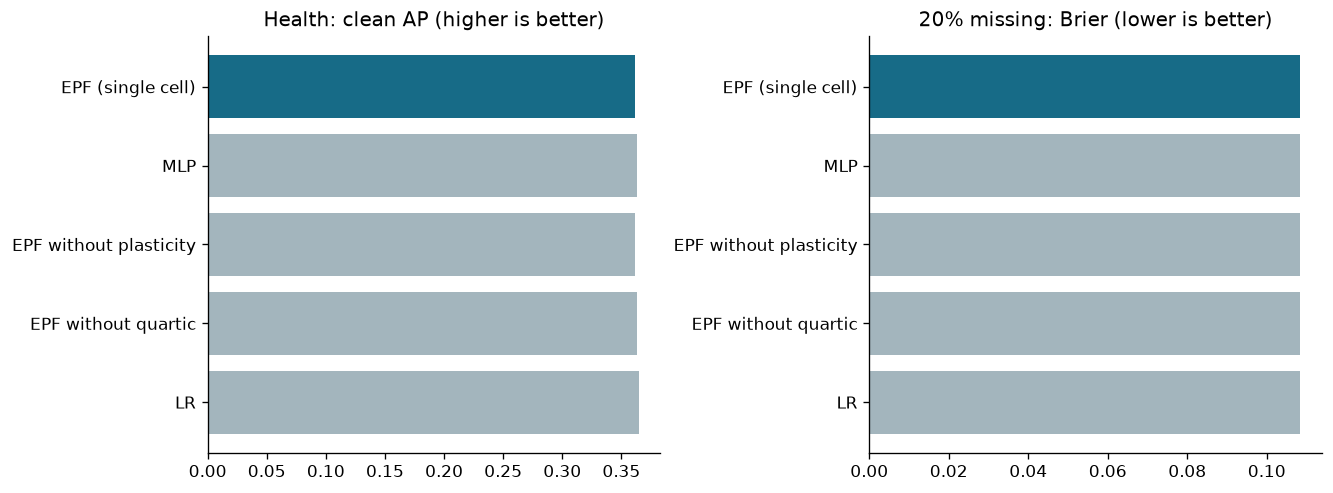

In [3]:
health=pd.DataFrame([{ "model":N[k],"macro_AP":v["clean"]["macro_ap"],"missing20_Brier":v["missing20"]["macro_brier"]} for k,v in R["health"]["models"].items()]).set_index("model")
display(health.round(6))
fig,axes=plt.subplots(1,2,figsize=(11,4),layout="constrained")
for ax,col,title in zip(axes,["macro_AP","missing20_Brier"],["Health: clean AP (higher is better)","20% missing: Brier (lower is better)"]):
    ax.barh(health.index,health[col],color=["#176b87"]+["#a3b5bd"]*(len(health)-1));ax.invert_yaxis();ax.set_title(title)
plt.show()

## 같은 64개 이력을 이용한 비선형 변환

시험 stream 20개는 모델 선택 뒤 생성했다. 목표는 `u[t−3]u[t−12]+u[t−1]u[t−32]`. 아래 NMSE는 이 출력만의 오차다. 나머지 네 지연 복원 출력은 공통 선형 초기화로 거의 해결되어 장기 기억의 근거로 쓰지 않는다.

,parameters,nonlinear_NMSE,selected_fit_seconds
model,,,
EPF (single cell),8525,0.000098,124.557058
MLP,8520,0.000798,11.313362
EPF without plasticity,8525,0.000111,85.796858
EPF without quartic,8525,0.000106,112.147955
GRU + attention,8657,0.000378,60.335196


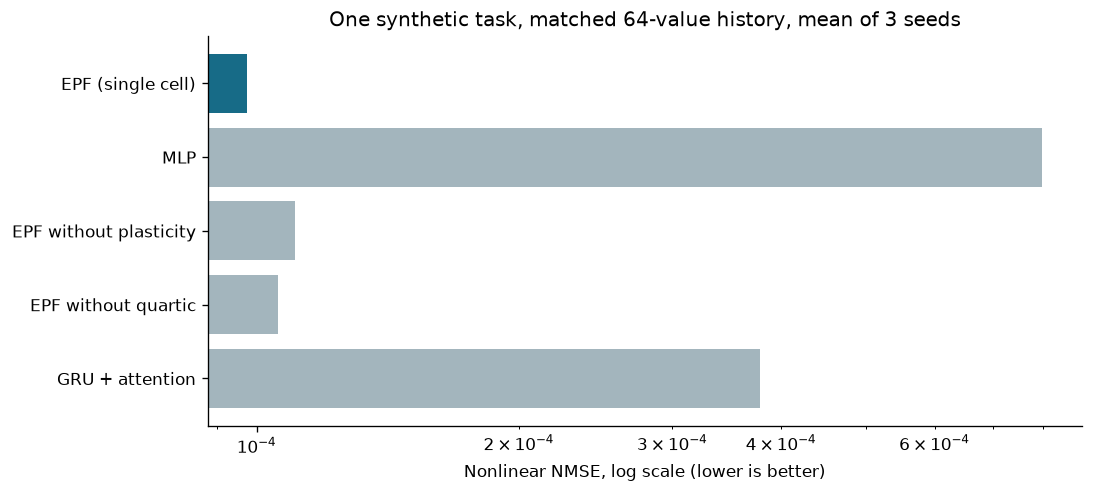

In [4]:
temporal=pd.DataFrame([{ "model":N[k],"parameters":v["parameters"][0],"nonlinear_NMSE":v["NMSE_mean"][4],"selected_fit_seconds":R["cost"]["training_temporal"][k]["mean_selected_fit_seconds"]} for k,v in R["temporal"]["models"].items()]).set_index("model")
display(temporal)
fig,ax=plt.subplots(figsize=(9,4),layout="constrained")
ax.barh(temporal.index,temporal.nonlinear_NMSE,color=["#176b87"]+["#a3b5bd"]*(len(temporal)-1));ax.set_xscale("log");ax.invert_yaxis();ax.set_xlabel("Nonlinear NMSE, log scale (lower is better)");ax.set_title("One synthetic task, matched 64-value history, mean of 3 seeds")
plt.show()

## 항 제거와 seed별 결과

가소성·quartic 항 제거 모델도 재학습했다. 두 경우 모두 전체 EPF가 나은 seed는 2/3이다. 발화 자체 제거는 실행하지 않았다. 구간은 고정된 3개 모델에 대해 시험 stream 전체를 2,000번 재표집한 조건부 구간이다. 전체 학습 불확실성이나 모든 항의 필수성을 뜻하지 않는다.

In [5]:
seed_table=pd.DataFrame({N[k]:[a[4] for a in v["NMSE_by_seed"]] for k,v in R["temporal"]["models"].items()},index=[42,43,44]).T
display(seed_table)
contrast=pd.DataFrame([{ "reference":N[k],"relative_reduction_pct":100*v["relative_nonlinear_NMSE_improvement"],"ci_low_pct":100*v["relative_improvement_ci95"][0],"ci_high_pct":100*v["relative_improvement_ci95"][1]} for k,v in R["temporal"]["paired"].items()]).set_index("reference")
display(contrast.round(3))

,42,43,44
EPF (single cell),0.000107,0.000098,0.000088
MLP,0.000791,0.000802,0.000799
EPF without plasticity,0.000126,0.000118,0.000087
EPF without quartic,0.000096,0.000111,0.000111
GRU + attention,0.000243,0.000498,0.000393


,relative_reduction_pct,ci_low_pct,ci_high_pct
reference,,,
MLP,87.768,87.055,88.478
EPF without plasticity,11.828,10.526,13.140
EPF without quartic,7.825,5.546,9.956
GRU + attention,74.185,73.145,75.153


## 학습과 정지 기준

학습률 후보와 최대 예산을 맞췄다. 최소 32/최대 320 epoch, 절대 MSE 1e−5, 24 epoch 정체와 2회 이상 학습률 감소. **GRU+attention seed44는 예산 320에 도달했고 best=319**이므로 모든 대조군의 수렴을 확정하지 않는다. 그림은 seed42 선택 trial이며 시험 점수로 trial을 선택하지 않았다.

,seed,model,epochs,best_epoch,stop
0,42,EPF (single cell),90,89,validation_plateau_after_lr_reductions
1,42,MLP,107,104,validation_plateau_after_lr_reductions
2,42,EPF without plasticity,81,81,validation_plateau_after_lr_reductions
3,42,EPF without quartic,95,95,validation_plateau_after_lr_reductions
4,42,GRU + attention,135,135,validation_plateau_after_lr_reductions
5,43,EPF (single cell),98,95,validation_plateau_after_lr_reductions
6,43,MLP,112,111,validation_plateau_after_lr_reductions
7,43,EPF without plasticity,93,91,validation_plateau_after_lr_reductions
8,43,EPF without quartic,84,83,validation_plateau_after_lr_reductions
9,43,GRU + attention,284,284,validation_plateau_after_lr_reductions


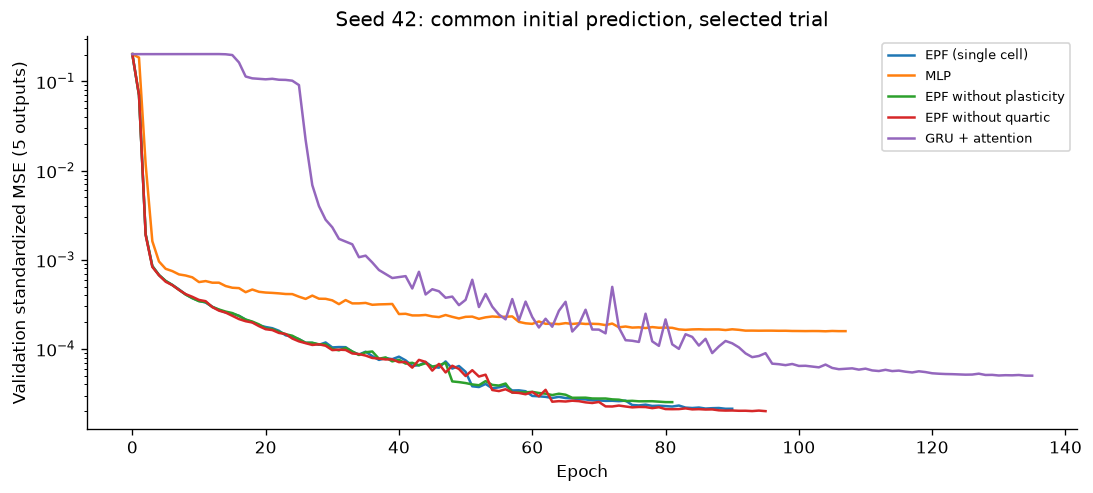

In [6]:
stops=[]
for run in R["temporal"]["seeds"]:
    for k,v in run["models"].items():stops.append({"seed":run["seed"],"model":N[k],"epochs":v["epochs"],"best_epoch":v["best_epoch"],"stop":v["stop_reason"]})
display(pd.DataFrame(stops))
fig,ax=plt.subplots(figsize=(9,4),layout="constrained")
for k,v in R["seed42_curves"].items():
    h=v["history"];ax.plot([0]+[a["epoch"] for a in h],[v["initial"]]+[a["validation_loss"] for a in h],label=N[k])
ax.set_yscale("log");ax.set_xlabel("Epoch");ax.set_ylabel("Validation standardized MSE (5 outputs)");ax.legend(fontsize=8);ax.set_title("Seed 42: common initial prediction, selected trial")
plt.show()

## 계산 비용과 활용 판단

선택 trial 평균 학습 시간은 EPF 124.6초, MLP 11.3초. 추론은 전처리·전송·보정을 제외하고 같은 장치에서 측정했다. 낮은 합성 오차를 더 빠른 추론으로 바꿔 말하지 않는다. 건강 선별은 LR을 기준 모델로 유지하며, 새 셀은 해당 비선형 과제에서 유효한 연구 후보로 평가한다.

,CPU_1_median_ms,CUDA_1024_median_ms
model,,
EPF (single cell),1.5173,6.4403
MLP,0.0206,0.2392
EPF without plasticity,1.1468,4.7955
EPF without quartic,1.5307,6.4525
GRU + attention,0.8635,0.7142


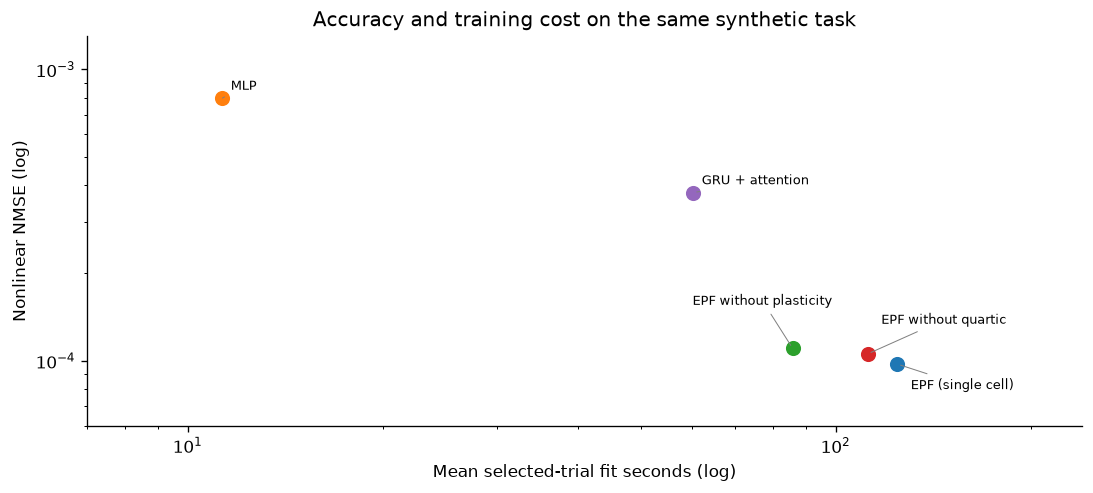

In [7]:
timings=pd.DataFrame([{ "model":N[k],"CPU_1_median_ms":v["cpu"][0]["median_ms_per_batch"],"CUDA_1024_median_ms":v["cuda"][1]["median_ms_per_batch"]} for k,v in R["cost"]["forward_latency"].items()]).set_index("model")
display(timings.round(4))
fig,ax=plt.subplots(figsize=(9,4),layout="constrained")
for name,row in temporal.iterrows():
    ax.scatter(row.selected_fit_seconds,row.nonlinear_NMSE,s=65);ax.annotate(name,(row.selected_fit_seconds,row.nonlinear_NMSE),xytext={"EPF (single cell)":(8,-15),"EPF without quartic":(8,18),"EPF without plasticity":(-60,26)}.get(name,(5,5)),textcoords="offset points",fontsize=8,arrowprops={"arrowstyle":"-","color":"gray","lw":.6})
ax.set_xscale("log");ax.set_yscale("log");ax.set_xlim(7,240);ax.set_ylim(6e-5,1.3e-3);ax.set_xlabel("Mean selected-trial fit seconds (log)");ax.set_ylabel("Nonlinear NMSE (log)");ax.set_title("Accuracy and training cost on the same synthetic task")
plt.show()

## 해석 범위

하나의 폐루프 셀을 구현·학습했다는 것은 확인했다. 합성 다항식 과제 1종에서의 오차 감소를 일반 표현력, 장기 기억, 의료 우월성으로 확장하지 않는다. Resonate-and-fire, differentiable plasticity, surrogate gradient는 이미 존재하는 선행 개념이다. 이들의 구체적 결합 구현이며 학술적 최초 여부는 확정하지 않았다.